# KPIs y Métricas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df_clientes = pd.read_excel("clientes.xlsx")
df_consolidado = pd.read_excel("consolidado.xlsx")


# Métricas de Cliente

In [3]:
# --- Métricas de Clientes ---

# Contar total de clientes únicos
total_clientes = df_clientes['id_cliente'].nunique()

# Obtener IDs de clientes activos (los que tienen compras)
ids_clientes_activos = df_consolidado['id_cliente'].unique()
clientes_activos_count = len(ids_clientes_activos)

# Calcular clientes inactivos
clientes_inactivos_count = total_clientes - clientes_activos_count

# Obtener DataFrame de clientes sin compras
df_clientes_sin_compras = df_clientes[~df_clientes['id_cliente'].isin(ids_clientes_activos)]

# Mostrar resultados
print(f"Total de clientes registrados: {total_clientes}")
print(f"Clientes activos (con compras): {clientes_activos_count}")
print(f"Clientes inactivos (sin compras): {clientes_inactivos_count}")
print(f"\nPorcentaje de clientes activos: {(clientes_activos_count/total_clientes)*100:.2f}%")
print(f"\nClientes sin compras:")
print(df_clientes_sin_compras)

Total de clientes registrados: 100
Clientes activos (con compras): 67
Clientes inactivos (sin compras): 33

Porcentaje de clientes activos: 67.00%

Clientes sin compras:
    id_cliente     nombre_cliente                        email       ciudad  \
3            4       Uma Martinez        uma.martinez@mail.com   Carlos Paz   
6            7      Emilia Castro       emilia.castro@mail.com   Rio Cuarto   
10          11     Helena Sanchez      helena.sanchez@mail.com  Villa Maria   
21          22   Franco Rodriguez    franco.rodriguez@mail.com  Alta Gracia   
23          24      Nicolas Silva       nicolas.silva@mail.com  Villa Maria   
31          32    Martina Alvarez     martina.alvarez@mail.com   Mendiolaza   
32          33      Franco Acosta       franco.acosta@mail.com   Rio Cuarto   
34          35       Yamila Lopez        yamila.lopez@mail.com   Mendiolaza   
37          38     Franco Herrera      franco.herrera@mail.com  Alta Gracia   
43          44      Camila Romero       

# Métricas de Venta

In [4]:
# --- Métricas de Ventas ---

# Contar total de ventas únicas
total_ventas = df_consolidado['id_venta'].nunique()

# Calcular ingreso total
ingreso_total = df_consolidado['importe'].sum()

# Calcular ticket promedio con protección contra división por cero

ticket_promedio = ingreso_total / total_ventas

# Mostrar resultados
print(f"Total de ventas realizadas: {total_ventas}")
print(f"Ingreso total: ${ingreso_total:,.2f}")
print(f"Ticket promedio: ${ticket_promedio:,.2f}")

Total de ventas realizadas: 120
Ingreso total: $2,651,417.00
Ticket promedio: $22,095.14


# Reportes agrupados

### Análisis de Métricas de Venta por Cliente

In [5]:
# Calcular métricas por cliente

# 1. Agrupar por cliente y calcular las métricas base.
metricas_cliente = df_consolidado.groupby('id_cliente').agg(
    nombre_cliente=('nombre_cliente', 'first'),
    email=('email', 'first'),
    ciudad=('ciudad', 'first'),
    total_compras=('id_venta', 'nunique'),
    importe_total=('importe', 'sum'),
    productos_diferentes=('nombre_producto', 'nunique'),
    categorias_diferentes=('nueva_categoria', 'nunique'),
    primera_compra=('fecha_venta', 'min'),
    ultima_compra=('fecha_venta', 'max')
)

# 2. Calcular el 'ticket_promedio'.
metricas_cliente['ticket_promedio'] = metricas_cliente['importe_total'] / metricas_cliente['total_compras']

# 3. Calcular los días totales entre la primera y la última compra.
metricas_cliente['dias_entre_compras'] = (metricas_cliente['ultima_compra'] - metricas_cliente['primera_compra']).dt.days

# 4. Calcular la 'frecuencia_compra'.
#    Esto generará:
#    - Un valor > 0 para clientes con compras en días distintos.
#    - NaN para clientes con una sola compra (división por cero).
metricas_cliente['frecuencia_compra'] = metricas_cliente['dias_entre_compras'] / (metricas_cliente['total_compras'] - 1)
metricas_cliente['frecuencia_compra'] = metricas_cliente['frecuencia_compra'].replace(0, np.nan)

# 5. Redondear los valores numéricos (NaN se ignora automáticamente).
columnas_a_redondear = ['importe_total', 'ticket_promedio', 'frecuencia_compra']
metricas_cliente[columnas_a_redondear] = metricas_cliente[columnas_a_redondear].round(1)

# 6. Reordenar las columnas para un análisis más intuitivo.
columnas_ordenadas = [
    # Identificación del cliente
    'nombre_cliente', 'email', 'ciudad',
    # Métricas de valor y volumen
    'total_compras', 'importe_total', 'ticket_promedio',
    # Métricas de comportamiento y tiempo
    'primera_compra', 'ultima_compra','dias_entre_compras','frecuencia_compra',
    # Métricas de variedad de productos
    'productos_diferentes', 'categorias_diferentes'
]

metricas_cliente = metricas_cliente[columnas_ordenadas]

# Mostrar las primeras filas con el nuevo orden para verificar.
metricas_cliente.head()


,nombre_cliente,email,ciudad,total_compras,importe_total,ticket_promedio,primera_compra,ultima_compra,dias_entre_compras,frecuencia_compra,productos_diferentes,categorias_diferentes
id_cliente,,,,,,,,,,,,
1,Mariana Lopez,mariana.lopez@mail.com,Carlos Paz,2,72448,36224.0,2024-02-06,2024-03-26,49,49.0,9,5
2,Nicolas Rojas,nicolas.rojas@mail.com,Carlos Paz,1,22150,22150.0,2024-04-12,2024-04-12,0,NaN,1,1
3,Hernan Martinez,hernan.martinez@mail.com,Rio Cuarto,1,33310,33310.0,2024-02-16,2024-02-16,0,NaN,4,2
5,Agustina Flores,agustina.flores@mail.com,Cordoba,4,132158,33039.5,2024-03-05,2024-06-25,112,37.3,13,3
6,Uma Medina,uma.medina@mail.com,Villa Maria,2,48878,24439.0,2024-01-24,2024-02-13,20,20.0,7,3


In [6]:
metricas_cliente.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67 entries, 1 to 100
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   nombre_cliente         67 non-null     object        
 1   email                  67 non-null     object        
 2   ciudad                 67 non-null     object        
 3   total_compras          67 non-null     int64         
 4   importe_total          67 non-null     int64         
 5   ticket_promedio        67 non-null     float64       
 6   primera_compra         67 non-null     datetime64[ns]
 7   ultima_compra          67 non-null     datetime64[ns]
 8   dias_entre_compras     67 non-null     int64         
 9   frecuencia_compra      37 non-null     float64       
 10  productos_diferentes   67 non-null     int64         
 11  categorias_diferentes  67 non-null     int64         
dtypes: datetime64[ns](2), float64(2), int64(5), object(3)
memory usage: 6.

In [7]:
metricas_cliente.describe()

,total_compras,importe_total,ticket_promedio,primera_compra,ultima_compra,dias_entre_compras,frecuencia_compra,productos_diferentes,categorias_diferentes
count,67.000000,67.000000,67.000000,67,67,67.000000,37.000000,67.000000,67.000000
mean,1.791045,39573.388060,23505.440299,2024-03-08 15:45:40.298507520,2024-04-14 01:25:58.208955136,36.402985,49.416216,4.955224,2.597015
min,1.000000,4283.000000,4283.000000,2024-01-02 00:00:00,2024-01-09 00:00:00,0.000000,7.000000,1.000000,1.000000
25%,1.000000,21554.500000,15193.600000,2024-01-23 12:00:00,2024-02-29 12:00:00,0.000000,20.000000,3.000000,2.000000
50%,2.000000,34326.000000,20920.000000,2024-02-23 00:00:00,2024-04-18 00:00:00,11.000000,37.300000,4.000000,3.000000
75%,2.000000,55557.500000,32200.500000,2024-04-29 00:00:00,2024-06-03 00:00:00,61.000000,73.500000,6.000000,3.000000
max,5.000000,132158.000000,61503.000000,2024-06-28 00:00:00,2024-06-28 00:00:00,154.000000,149.000000,13.000000,5.000000
std,0.946081,23945.209866,12126.441264,NaN,NaN,48.751709,38.603702,2.676683,1.045332


In [8]:
# Guardando metricas_cliente en un archivo csv
metricas_cliente.to_csv("metricas_cliente.csv")

### Visualizaciones Métricas por Cliente

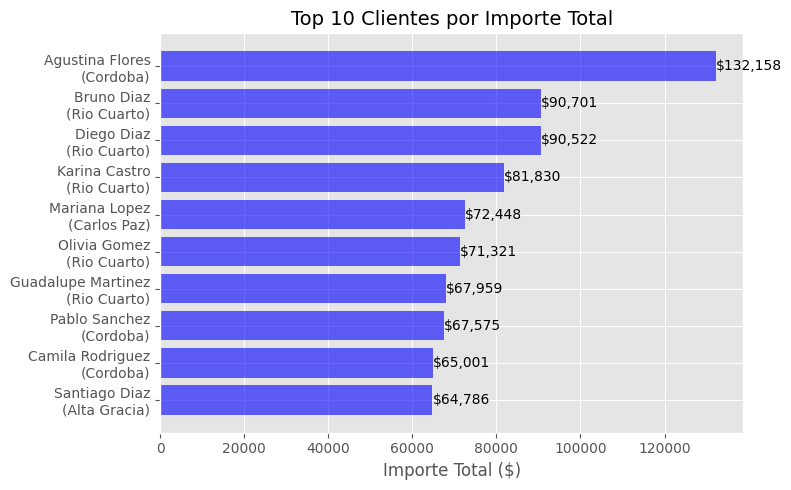

In [9]:
# Top Ten Clientes por Importe

# Configurar el estilo
plt.style.use('ggplot')

# Obtener top 10 clientes por importe total
top_10_clientes = metricas_cliente.nlargest(10, 'importe_total').copy()
top_10_clientes = top_10_clientes.sort_values('importe_total')

# Crear figura con tamaño apropiado
plt.figure(figsize=(8, 5))

# Crear barras horizontales
bars = plt.barh(range(len(top_10_clientes)), top_10_clientes['importe_total'], 
                color='blue', alpha=0.6)

# Personalizar el gráfico
plt.title('Top 10 Clientes por Importe Total', fontsize=14)
plt.xlabel('Importe Total ($)', fontsize=12)

# Personalizar eje Y con nombres y ciudades
labels = [f'{row.nombre_cliente}\n({row.ciudad})' 
          for idx, row in top_10_clientes.iterrows()]
plt.yticks(range(len(top_10_clientes)), labels)

# Añadir valores en las barras
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, 
             f'${width:,.0f}',
             ha='left', va='center')

plt.tight_layout()

plt.show()

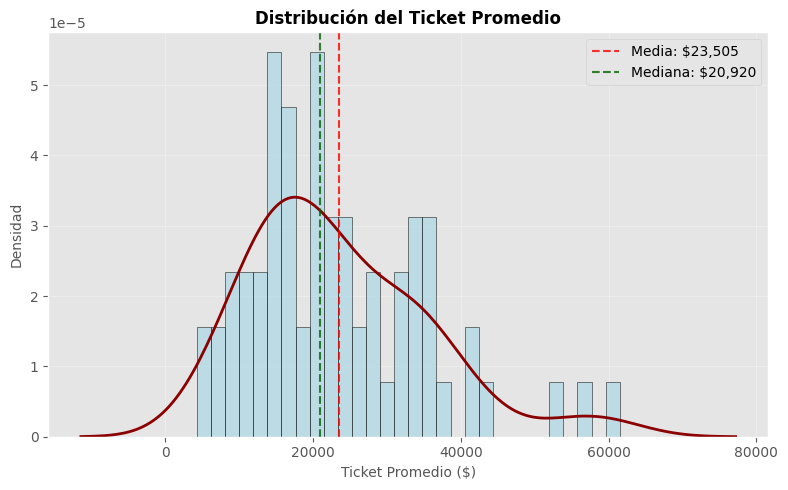


Estadísticas Descriptivas del Ticket Promedio:
count       67.00
mean     23505.44
std      12126.44
min       4283.00
25%      15193.60
50%      20920.00
75%      32200.50
max      61503.00
Name: ticket_promedio, dtype: float64


In [10]:
# Distribución de ticket promedio

# Configurar el estilo
plt.style.use('ggplot')

# Crear figura
plt.figure(figsize=(8, 5))

# Crear histograma con línea de densidad
plt.hist(metricas_cliente['ticket_promedio'], bins=30, density=True, alpha=0.7,
         color='lightblue', edgecolor='black')

# Añadir la curva de densidad
sns.kdeplot(data=metricas_cliente['ticket_promedio'], color='darkred', linewidth=2)

# Añadir líneas verticales para estadísticas importantes
plt.axvline(metricas_cliente['ticket_promedio'].mean(), color='red', linestyle='--', alpha=0.8,
            label=f'Media: ${metricas_cliente["ticket_promedio"].mean():,.0f}')
plt.axvline(metricas_cliente['ticket_promedio'].median(), color='darkgreen', linestyle='--', alpha=0.8,
            label=f'Mediana: ${metricas_cliente["ticket_promedio"].median():,.0f}')

# Personalizar el gráfico
plt.title('Distribución del Ticket Promedio', fontsize=12, fontweight='bold')
plt.xlabel('Ticket Promedio ($)', fontsize=10)
plt.ylabel('Densidad', fontsize=10)

# Añadir leyenda
plt.legend()

# Añadir grid para mejor lectura
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar estadísticas descriptivas
print("\nEstadísticas Descriptivas del Ticket Promedio:")
stats = metricas_cliente['ticket_promedio'].describe().round(2)
print(stats)

C:\Users\capab\AppData\Local\Temp\ipykernel_18468\140282255.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(v, i, f' {v:,} clientes\n ${metricas_por_ciudad["Ticket Promedio"][i]:,.0f} ticket prom.',


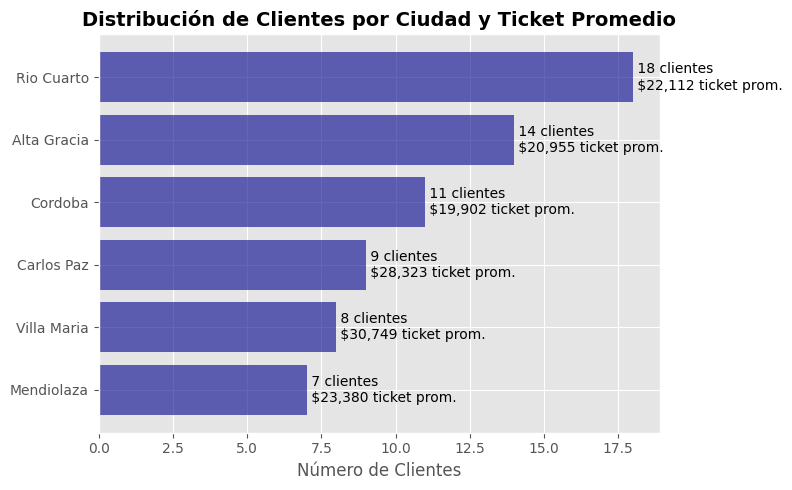

In [11]:
# Distribución geográfica de clientes y ticket promedio por ciudad

# Configurar el estilo
plt.style.use('ggplot')

# Calcular métricas por ciudad
metricas_por_ciudad = metricas_cliente.groupby('ciudad').agg({
    'nombre_cliente': 'count',
    'importe_total': 'mean',
    'ticket_promedio': 'mean'
}).round(2)

metricas_por_ciudad.columns = ['Número de Clientes', 'Importe Promedio', 'Ticket Promedio']

# Crear gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(8, 5))

# Ordenar por número de clientes
metricas_por_ciudad = metricas_por_ciudad.sort_values('Número de Clientes', ascending=True)

# Crear barras
y_pos = np.arange(len(metricas_por_ciudad.index))
ax.barh(y_pos, metricas_por_ciudad['Número de Clientes'], color='darkblue', alpha=0.6,
        label='Número de Clientes')

# Personalizar el gráfico
ax.set_yticks(y_pos)
ax.set_yticklabels(metricas_por_ciudad.index)
ax.set_xlabel('Número de Clientes')
ax.set_title('Distribución de Clientes por Ciudad y Ticket Promedio', fontsize=14, fontweight='bold')

# Añadir valores en las barras
for i, v in enumerate(metricas_por_ciudad['Número de Clientes']):
    ax.text(v, i, f' {v:,} clientes\n ${metricas_por_ciudad["Ticket Promedio"][i]:,.0f} ticket prom.',
            va='center')

plt.tight_layout()
plt.show()

C:\Users\capab\AppData\Local\Temp\ipykernel_18468\1443638195.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([metricas_cliente[metricas_cliente['ciudad'] == ciudad]['ticket_promedio']


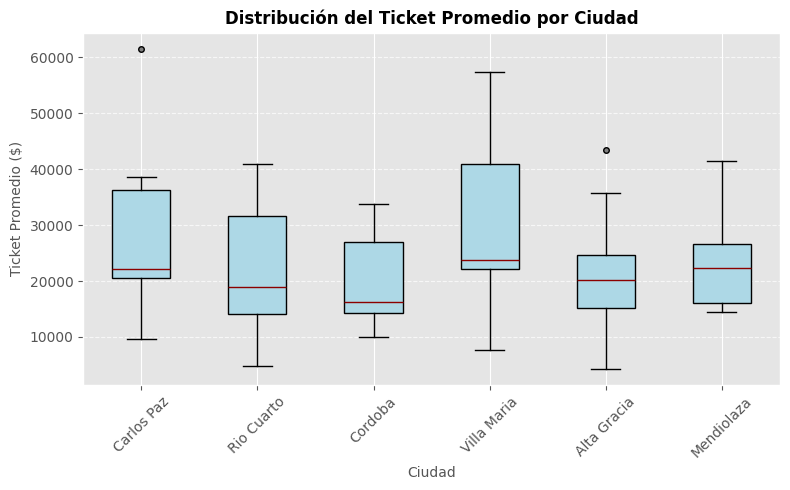


Estadísticas del Ticket Promedio por Ciudad:
             count      mean       std      min       25%      50%       75%  \
ciudad                                                                         
Alta Gracia   14.0  20954.94  11222.35   4283.0  15201.15  20225.0  24677.62   
Carlos Paz     9.0  28322.61  15884.56   9553.5  20544.00  22150.0  36224.00   
Cordoba       11.0  19901.76   8705.05   9961.0  14254.75  16250.2  27017.50   
Mendiolaza     7.0  23380.07   9573.19  14391.0  16025.00  22281.5  26700.50   
Rio Cuarto    18.0  22112.11  10203.02   4900.0  14134.75  18982.6  31656.00   
Villa Maria    8.0  30749.25  17215.29   7752.0  22133.25  23785.5  40936.25   

                 max  
ciudad                
Alta Gracia  43475.0  
Carlos Paz   61503.0  
Cordoba      33787.5  
Mendiolaza   41537.0  
Rio Cuarto   40915.0  
Villa Maria  57287.0  


In [12]:
# Distribución ticket promedio por ciudad (boxplot)

# Configurar el estilo
plt.style.use('ggplot')

# Crear figura
plt.figure(figsize=(8, 5))

# Crear boxplot
plt.boxplot([metricas_cliente[metricas_cliente['ciudad'] == ciudad]['ticket_promedio'] 
             for ciudad in metricas_cliente['ciudad'].unique()],
            labels=metricas_cliente['ciudad'].unique(),
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='black'),
            medianprops=dict(color='darkred'),
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=4))

# Personalizar el gráfico
plt.title('Distribución del Ticket Promedio por Ciudad', fontsize=12, fontweight='bold')
plt.ylabel('Ticket Promedio ($)', fontsize=10)
plt.xlabel('Ciudad', fontsize=10)
plt.xticks(rotation=45)

# Añadir grid en el eje Y para mejor lectura
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Mostrar estadísticas resumidas
print("\nEstadísticas del Ticket Promedio por Ciudad:")
print(metricas_cliente.groupby('ciudad')['ticket_promedio'].describe().round(2))

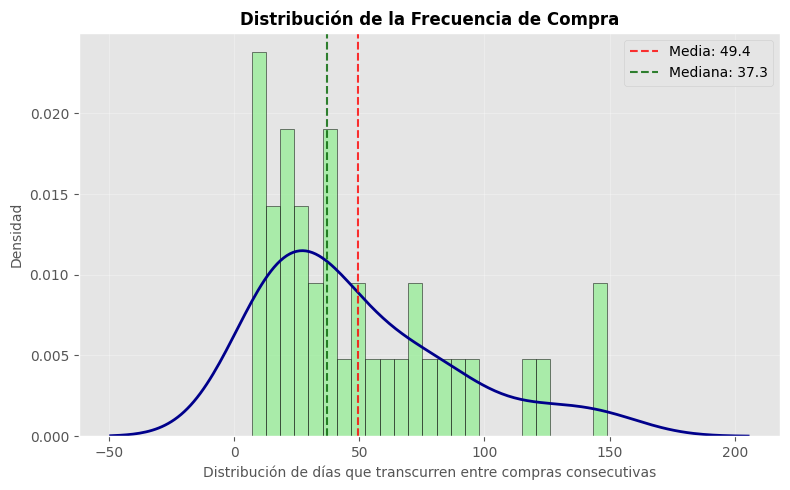


Estadísticas Descriptivas de la Frecuencia de Compra:
count     37.00
mean      49.42
std       38.60
min        7.00
25%       20.00
50%       37.30
75%       73.50
max      149.00
Name: frecuencia_compra, dtype: float64


In [13]:
# Distribución de frecuencia de compra

# Configurar el estilo
plt.style.use('ggplot')

# Crear figura
plt.figure(figsize=(8, 5))

# Crear histograma con línea de densidad
plt.hist(metricas_cliente['frecuencia_compra'], bins=25, density=True, alpha=0.7,
         color='lightgreen', edgecolor='black')

# Añadir la curva de densidad
sns.kdeplot(data=metricas_cliente['frecuencia_compra'], color='darkblue', linewidth=2)

# Añadir líneas verticales para estadísticas importantes
plt.axvline(metricas_cliente['frecuencia_compra'].mean(), color='red', linestyle='--', alpha=0.8,
            label=f'Media: {metricas_cliente["frecuencia_compra"].mean():.1f}')
plt.axvline(metricas_cliente['frecuencia_compra'].median(), color='darkgreen', linestyle='--', alpha=0.8,
            label=f'Mediana: {metricas_cliente["frecuencia_compra"].median():.1f}')

# Personalizar el gráfico
plt.title('Distribución de la Frecuencia de Compra', fontsize=12, fontweight='bold')
plt.xlabel('Distribución de días que transcurren entre compras consecutivas', fontsize=10)
plt.ylabel('Densidad', fontsize=10)

# Añadir leyenda
plt.legend()

# Añadir grid para mejor lectura
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar estadísticas descriptivas
print("\nEstadísticas Descriptivas de la Frecuencia de Compra:")
stats = metricas_cliente['frecuencia_compra'].describe().round(2)
print(stats)

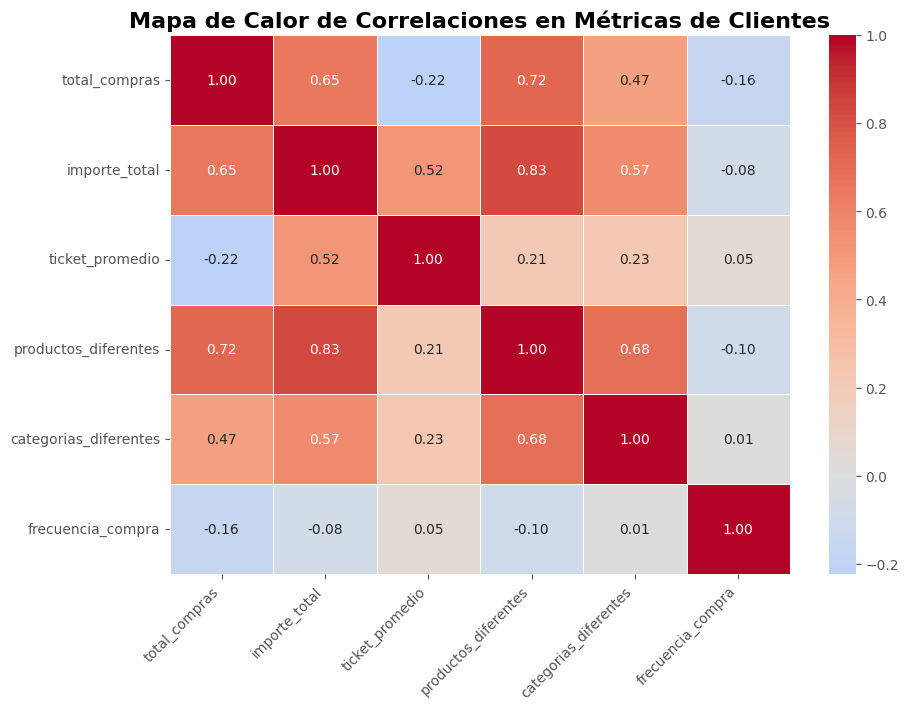

In [14]:
# Crear matriz de correlación y heatmap


# Seleccionar variables numéricas relevantes para la correlación
vars_correlacion = [
    'total_compras', 
    'importe_total', 
    'ticket_promedio', 
    'productos_diferentes', 
    'categorias_diferentes', 
    'frecuencia_compra'
]

# Calcular la matriz de correlación
correlation_matrix = metricas_cliente[vars_correlacion].corr()

# Crear el heatmap
plt.style.use('ggplot')
# Usar subplots para tener más control sobre la figura y los ejes
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    correlation_matrix, 
    annot=True,          # Mostrar los valores en el mapa
    cmap='coolwarm',     # Usar un mapa de colores frío/cálido
    fmt='.2f',           # Formatear los números a 2 decimales
    linewidths=.5,       # Añadir líneas entre las celdas
    center=0,            # Centrar la escala de colores en 0
    ax=ax                # Especificar los ejes a usar
)

ax.set_title('Mapa de Calor de Correlaciones en Métricas de Clientes', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

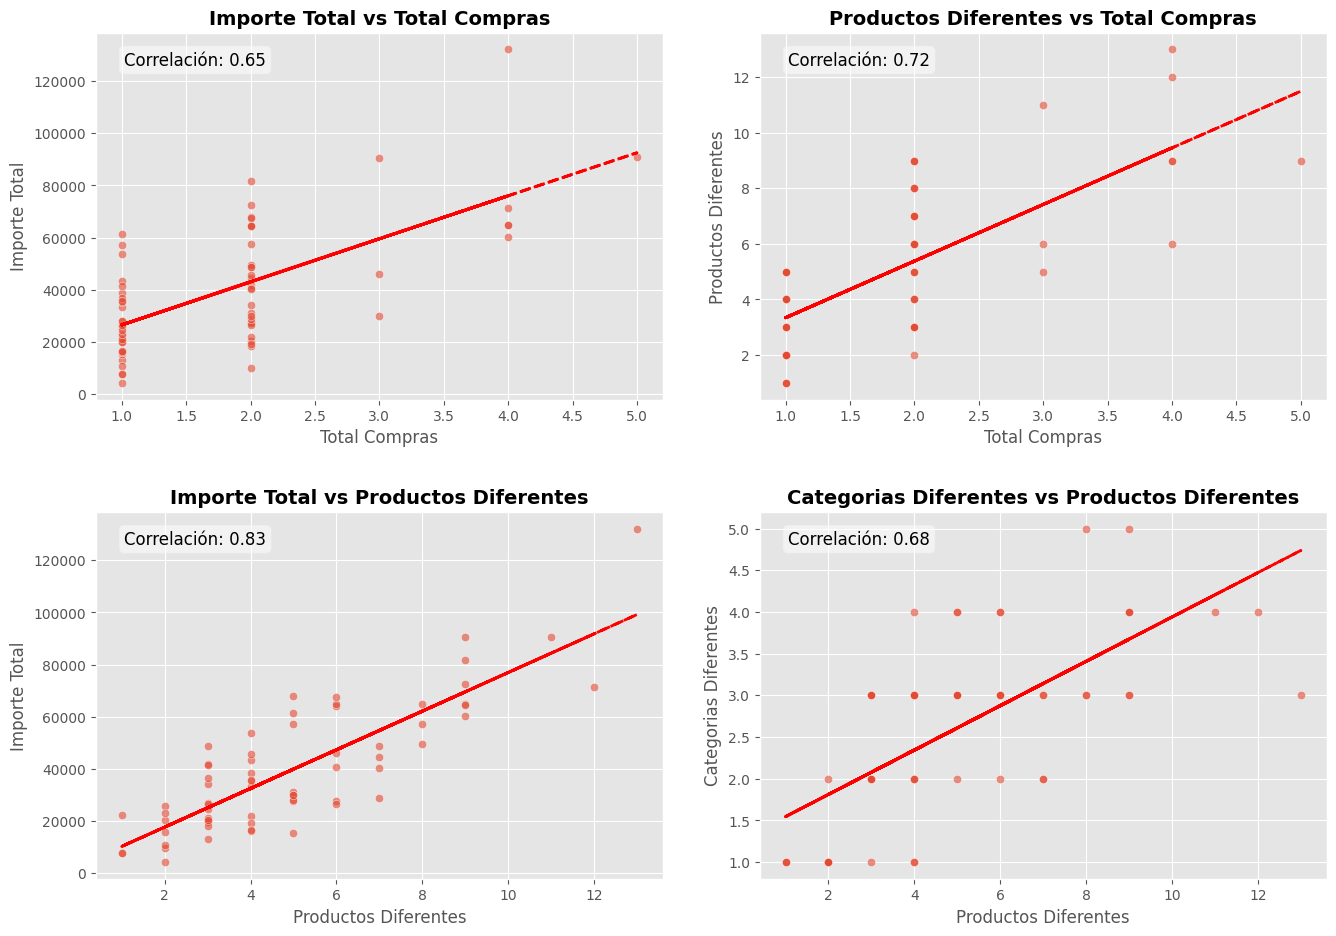

In [15]:
# Creando Scatterplots

# Pares de variables para las correlaciones solicitadas

var_pairs = [
    ('total_compras', 'importe_total'),          # Correlación ~0.65
    ('total_compras', 'productos_diferentes'),   # Correlación ~0.72
    ('productos_diferentes', 'importe_total'),   # Correlación ~0.83
    ('productos_diferentes', 'categorias_diferentes') # Correlación ~0.68
]

# Crear un subplot de 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # Aplanar el array de ejes para iterar fácilmente

# Iterar sobre los pares de variables y los ejes del subplot
for i, (x_var, y_var) in enumerate(var_pairs):
    ax = axes[i]
    
    # Calcular la correlación
    correlation = metricas_cliente[x_var].corr(metricas_cliente[y_var])
    
    # Crear el scatterplot
    sns.scatterplot(data=metricas_cliente, x=x_var, y=y_var, ax=ax, alpha=0.6)
    
    # Calcular y añadir la línea de tendencia
    z = np.polyfit(metricas_cliente[x_var], metricas_cliente[y_var], 1)
    p = np.poly1d(z)
    ax.plot(metricas_cliente[x_var], p(metricas_cliente[x_var]), "r--", linewidth=2)
    
    # Añadir el valor de correlación en el gráfico
    ax.text(0.05, 0.95, f'Correlación: {correlation:.2f}', transform=ax.transAxes,
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.5))
            
    # Configurar títulos y etiquetas
    ax.set_title(f'{y_var.replace("_", " ").title()} vs {x_var.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    ax.set_xlabel(x_var.replace("_", " ").title(), fontsize=12)
    ax.set_ylabel(y_var.replace("_", " ").title(), fontsize=12)
    ax.grid(True)

# Ajustar el layout y mostrar el gráfico
plt.tight_layout(pad=3.0)
plt.show()

### Análisis de Métricas de Venta por Tipo y Categoría de Producto

In [16]:
# Crear reporte de ventas por producto

# Extraer el mes y año de la fecha de venta
df_consolidado['mes_venta'] = df_consolidado['fecha_venta'].dt.strftime('%Y-%m')

# Agrupar y agregar métricas, nombrando las columnas directamente.
metricas_producto = df_consolidado.groupby(['nueva_categoria', 'nombre_producto', 'mes_venta']).agg(
    n_ventas=('id_venta', 'nunique'),
    unidades_vendidas=('cantidad', 'sum'),
    importe_total=('importe', 'sum'),
    importe_promedio=('importe', 'mean'),
    importe_std=('importe', 'std'),
    precio_unitario=('precio_unitario', 'first'),
    n_clientes_unicos=('id_cliente', 'nunique')
).reset_index()

# Redondear los valores numéricos al final para mantener la precisión en cálculos intermedios.
metricas_producto = metricas_producto.round(1)

In [17]:
metricas_producto.head()

,nueva_categoria,nombre_producto,mes_venta,n_ventas,unidades_vendidas,importe_total,importe_promedio,importe_std,precio_unitario,n_clientes_unicos
0,Alimentos,Aceite de Girasol 1L,2024-01,2,7,6020,3010.0,608.1,860,2
1,Alimentos,Aceite de Girasol 1L,2024-02,1,4,3440,3440.0,NaN,860,1
2,Alimentos,Aceite de Girasol 1L,2024-03,2,7,6020,3010.0,1824.3,860,2
3,Alimentos,Aceite de Girasol 1L,2024-05,1,1,860,860.0,NaN,860,1
4,Alimentos,Aceitunas Negras 200g,2024-01,1,2,4788,4788.0,NaN,2394,1


In [18]:
metricas_producto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259 entries, 0 to 258
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   nueva_categoria    259 non-null    object 
 1   nombre_producto    259 non-null    object 
 2   mes_venta          259 non-null    object 
 3   n_ventas           259 non-null    int64  
 4   unidades_vendidas  259 non-null    int64  
 5   importe_total      259 non-null    int64  
 6   importe_promedio   259 non-null    float64
 7   importe_std        69 non-null     float64
 8   precio_unitario    259 non-null    int64  
 9   n_clientes_unicos  259 non-null    int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 20.4+ KB


In [19]:
metricas_producto.describe()

,n_ventas,unidades_vendidas,importe_total,importe_promedio,importe_std,precio_unitario,n_clientes_unicos
count,259.000000,259.000000,259.000000,259.000000,69.000000,259.000000,259.000000
mean,1.308880,3.922780,10237.131274,7737.369884,2854.321739,2686.397683,1.308880
std,0.568179,2.413187,8274.631833,5099.931095,2458.682315,1331.663260,0.568179
min,1.000000,1.000000,272.000000,272.000000,0.000000,272.000000,1.000000
25%,1.000000,2.000000,4432.500000,3490.000000,1176.600000,1618.500000,1.000000
50%,1.000000,3.000000,8276.000000,7035.000000,2466.400000,2520.000000,1.000000
75%,2.000000,5.000000,13355.000000,10284.000000,3561.700000,3878.000000,2.000000
max,4.000000,15.000000,47146.000000,24865.000000,10963.000000,4982.000000,4.000000


In [20]:
# Guardar el reporte en un archivo CSV
metricas_producto.to_csv("metricas_producto.csv", index=False)

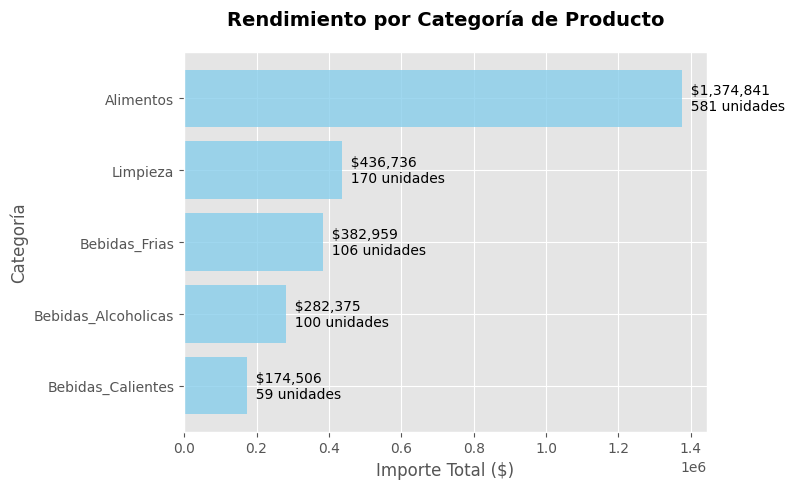

In [21]:
# Gráfico rendimiento por categoría de producto

# Agrupar datos por categoría
metricas_categoria = metricas_producto.groupby('nueva_categoria').agg({
    'importe_total': 'sum',
    'unidades_vendidas': 'sum',
    'nombre_producto': 'count'  # Cantidad de productos únicos
}).reset_index()

# Ordenar por importe total
metricas_categoria = metricas_categoria.sort_values('importe_total', ascending=True)

# Configurar el estilo
plt.style.use('ggplot')

# Crear figura con tamaño apropiado
fig, ax = plt.subplots(figsize=(8, 5))

# Crear barras horizontales
y_pos = np.arange(len(metricas_categoria))
bars = ax.barh(y_pos, metricas_categoria['importe_total'], 
               color='skyblue', alpha=0.8,
               label='Importe Total')

# Personalizar el gráfico
ax.set_title('Rendimiento por Categoría de Producto', fontsize=14, pad=20, fontweight='bold')
ax.set_xlabel('Importe Total ($)', fontsize=12)
ax.set_ylabel('Categoría', fontsize=12)

# Configurar etiquetas del eje Y
ax.set_yticks(y_pos)
ax.set_yticklabels(metricas_categoria['nueva_categoria'])

# Añadir etiquetas en las barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    units = metricas_categoria.iloc[i]['unidades_vendidas']
    
    # Formatear el importe total con separadores de miles y dos decimales
    importe = f'${width:,.0f}'
    # Formatear unidades vendidas con separadores de miles
    units_text = f'{units:,.0f} unidades'
    
    # Posicionar las etiquetas
    ax.text(width, bar.get_y() + bar.get_height()/2,
            f'  {importe}\n  {units_text}',
            va='center', ha='left', fontsize=10)

# Ajustar los márgenes
plt.tight_layout()

# Mostrar el gráfico
plt.show()

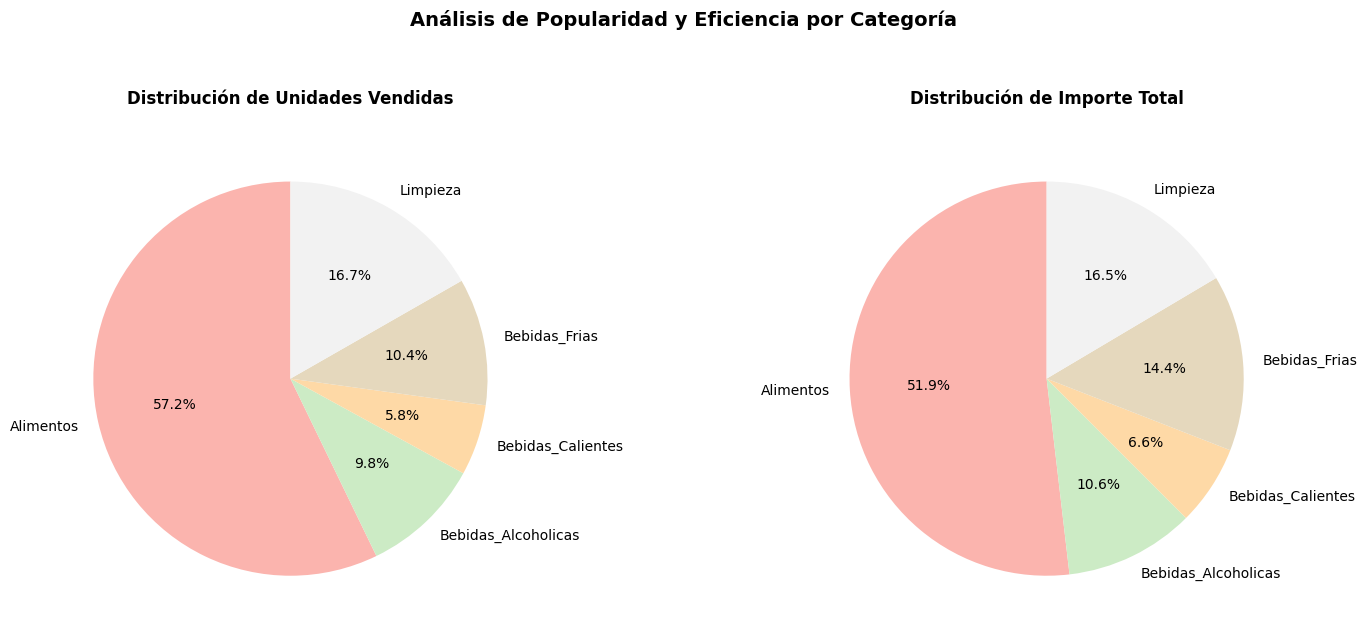


Métricas por Categoría:
       nueva_categoria unidades_vendidas  importe_total  porcentaje_unidades  \
0            Alimentos               581  $1,374,841.00                57.19   
1  Bebidas_Alcoholicas               100    $282,375.00                 9.84   
2    Bebidas_Calientes                59    $174,506.00                 5.81   
3        Bebidas_Frias               106    $382,959.00                10.43   
4             Limpieza               170    $436,736.00                16.73   

   porcentaje_importe  
0               51.85  
1               10.65  
2                6.58  
3               14.44  
4               16.47  


In [21]:

# Gráfico de popularidad y eficiencia por categoría

#  Agrupar datos por categoría para análisis de popularidad y eficiencia
popularidad_eficiencia = metricas_producto.groupby('nueva_categoria').agg({
    'unidades_vendidas': 'sum',
    'importe_total': 'sum'
}).reset_index()

# Calcular el tamaño total del mercado
total_unidades = popularidad_eficiencia['unidades_vendidas'].sum()
total_importe = popularidad_eficiencia['importe_total'].sum()

# Calcular porcentajes
popularidad_eficiencia['porcentaje_unidades'] = (popularidad_eficiencia['unidades_vendidas'] / total_unidades) * 100
popularidad_eficiencia['porcentaje_importe'] = (popularidad_eficiencia['importe_total'] / total_importe) * 100

# Configurar el estilo
plt.style.use('ggplot')

# Crear figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de pastel para unidades vendidas
colors = plt.cm.Pastel1(np.linspace(0, 1, len(popularidad_eficiencia)))
wedges1, texts1, autotexts1 = ax1.pie(popularidad_eficiencia['porcentaje_unidades'], 
                                     labels=popularidad_eficiencia['nueva_categoria'],
                                     colors=colors,
                                     autopct='%1.1f%%',
                                     startangle=90)

# Gráfico de pastel para importe total
wedges2, texts2, autotexts2 = ax2.pie(popularidad_eficiencia['porcentaje_importe'],
                                     labels=popularidad_eficiencia['nueva_categoria'],
                                     colors=colors,
                                     autopct='%1.1f%%',
                                     startangle=90)

# Personalizar los gráficos
ax1.set_title('Distribución de Unidades Vendidas', fontsize=12, pad=20, fontweight='bold')
ax2.set_title('Distribución de Importe Total', fontsize=12, pad=20, fontweight='bold')

# Ajustar el aspecto
plt.suptitle('Análisis de Popularidad y Eficiencia por Categoría', fontsize=14, y=1.05, fontweight='bold')

# Ajustar los márgenes
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# Mostrar tabla de resultados
print("\nMétricas por Categoría:")
resultado_tabla = popularidad_eficiencia.round(2)
resultado_tabla['unidades_vendidas'] = resultado_tabla['unidades_vendidas'].map('{:,.0f}'.format)
resultado_tabla['importe_total'] = resultado_tabla['importe_total'].map('${:,.2f}'.format)
print(resultado_tabla)

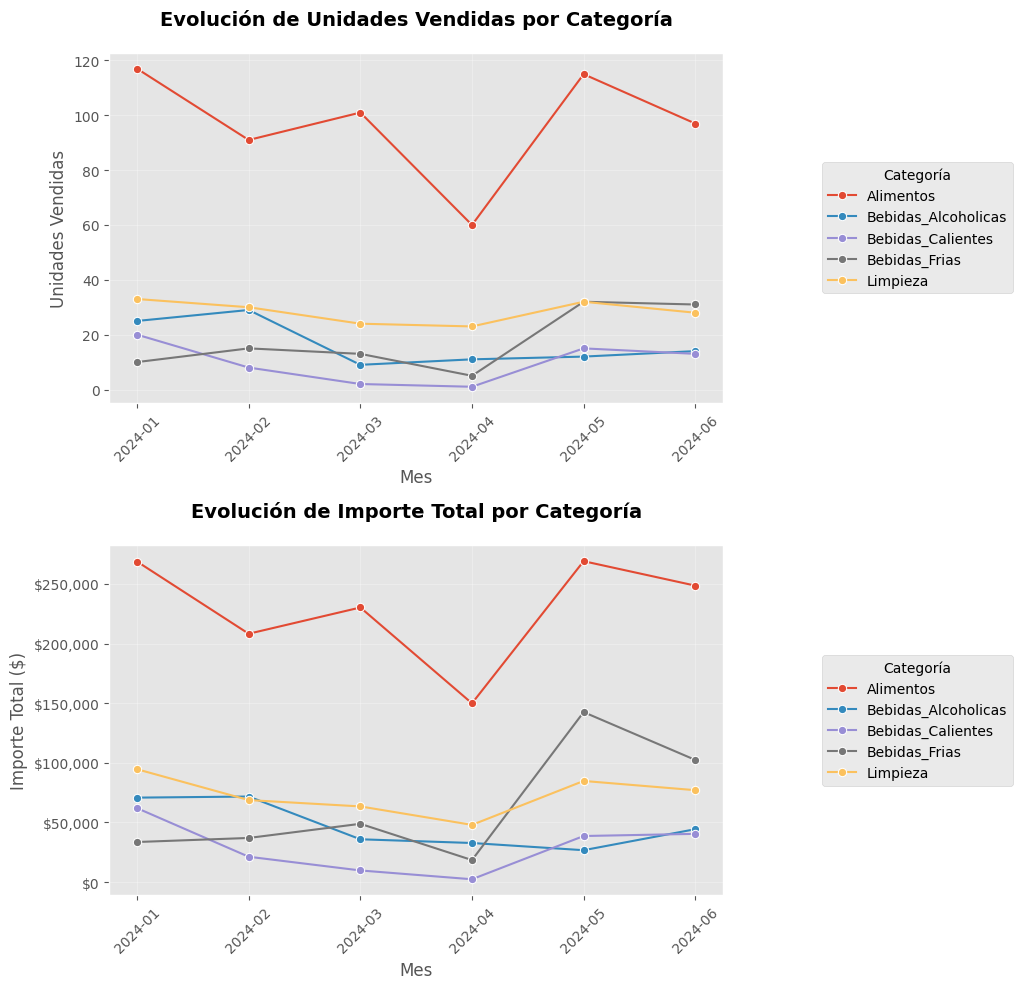


Estadísticas mensuales por categoría:

Unidades vendidas por mes y categoría:
mes_venta            2024-01  2024-02  2024-03  2024-04  2024-05  2024-06
nueva_categoria                                                          
Alimentos                117       91      101       60      115       97
Bebidas_Alcoholicas       25       29        9       11       12       14
Bebidas_Calientes         20        8        2        1       15       13
Bebidas_Frias             10       15       13        5       32       31
Limpieza                  33       30       24       23       32       28

Importe total por mes y categoría:
mes_venta            2024-01  2024-02  2024-03  2024-04  2024-05  2024-06
nueva_categoria                                                          
Alimentos             268760   208244   230257   149909   269086   248585
Bebidas_Alcoholicas    70829    71747    35905    32785    26749    44360
Bebidas_Calientes      61999    21261     9766     2383    38643    404

In [22]:
# Análisis de ventas mensuales por categoría

# Agrupar datos por mes y categoría
ventas_mensuales = metricas_producto.groupby(['mes_venta', 'nueva_categoria']).agg({
    'importe_total': 'sum',
    'unidades_vendidas': 'sum'
}).reset_index()

# Crear visualizaciones
plt.style.use('ggplot')

# Crear figura con dos subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Gráfico de evolución de unidades vendidas
sns.lineplot(data=ventas_mensuales, x='mes_venta', y='unidades_vendidas', 
             hue='nueva_categoria', marker='o', ax=ax1)

# Personalizar el primer gráfico
ax1.set_title('Evolución de Unidades Vendidas por Categoría', fontsize=14, pad=20, fontweight='bold')
ax1.set_xlabel('Mes', fontsize=12)
ax1.set_ylabel('Unidades Vendidas', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)
# Mover la leyenda fuera del gráfico a la derecha y centrada
ax1.legend(bbox_to_anchor=(1.15, 0.5), loc='center left', title='Categoría')

# Gráfico de evolución de importe total
sns.lineplot(data=ventas_mensuales, x='mes_venta', y='importe_total', 
             hue='nueva_categoria', marker='o', ax=ax2)

# Personalizar el segundo gráfico
ax2.set_title('Evolución de Importe Total por Categoría', fontsize=14, pad=20, fontweight='bold')
ax2.set_xlabel('Mes', fontsize=12)
ax2.set_ylabel('Importe Total ($)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)
# Mover la leyenda fuera del gráfico a la derecha y centrada
ax2.legend(bbox_to_anchor=(1.15, 0.5), loc='center left', title='Categoría')

# Formatear valores del eje Y para el segundo gráfico
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Ajustar el layout con más espacio para las leyendas a la derecha
plt.tight_layout(rect=[0, 0, 0.9, 1])  # Ajustar el espacio para las leyendas

# Mostrar el gráfico
plt.show()

# Mostrar estadísticas por mes y categoría
print("\nEstadísticas mensuales por categoría:")
stats_mensuales = ventas_mensuales.pivot_table(
    index='nueva_categoria',
    columns='mes_venta',
    values=['unidades_vendidas', 'importe_total'],
    aggfunc='sum'
).round(2)

print("\nUnidades vendidas por mes y categoría:")
print(stats_mensuales['unidades_vendidas'])
print("\nImporte total por mes y categoría:")
print(stats_mensuales['importe_total'])

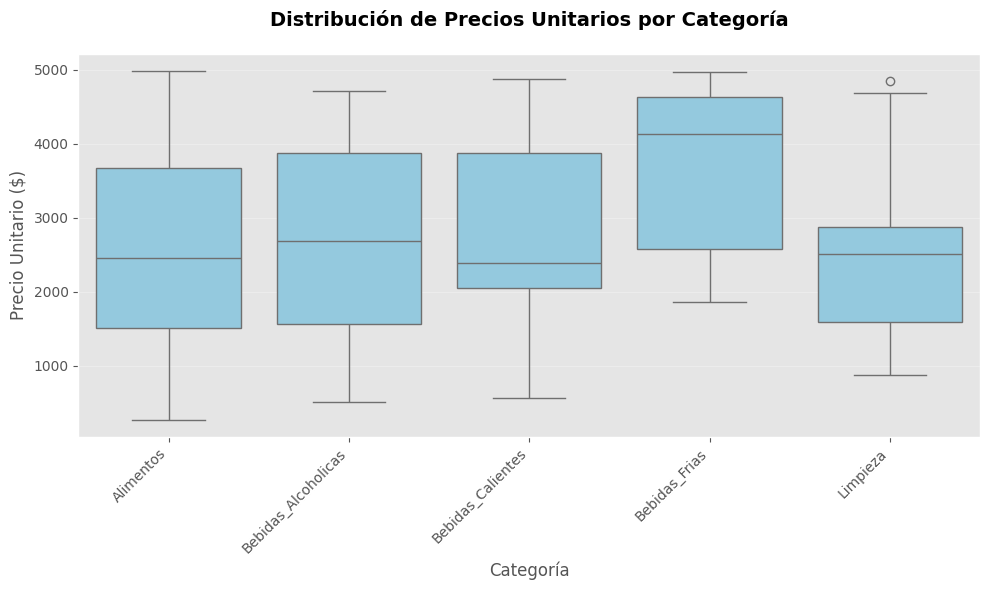


Estadísticas de Precios por Categoría (basado en productos únicos):
                     count     mean      std     min     25%     50%      75%  \
nueva_categoria                                                                 
Alimentos             56.0  2553.88  1372.73   272.0  1504.5  2461.0  3671.00   
Bebidas_Alcoholicas    9.0  2702.00  1365.50   508.0  1561.0  2684.0  3876.00   
Bebidas_Calientes      5.0  2753.40  1672.94   570.0  2053.0  2383.0  3878.00   
Bebidas_Frias         10.0  3669.70  1211.33  1856.0  2577.5  4130.0  4637.25   
Limpieza              15.0  2540.73  1259.02   872.0  1586.5  2512.0  2872.50   

                        max  
nueva_categoria              
Alimentos            4982.0  
Bebidas_Alcoholicas  4719.0  
Bebidas_Calientes    4883.0  
Bebidas_Frias        4973.0  
Limpieza             4854.0  


In [23]:
# Gráfico de distribución de precios por categoría (Boxplot)

# Creamos un nuevo DataFrame donde cada producto aparece solo una vez con su precio.
# Usamos .drop_duplicates() sobre las columnas de producto y categoría.

df_precios_unicos = metricas_producto[['nueva_categoria', 'nombre_producto', 'precio_unitario']].drop_duplicates()

# Gráfico de distribución de precios por categoría (Boxplot)

# Configurar el estilo
plt.style.use('ggplot')

# Crear figura con tamaño apropiado
plt.figure(figsize=(10, 6))

# Crear boxplot usando el DataFrame corregido 'df_precios_unicos'
sns.boxplot(data=df_precios_unicos, # <--- CORRECCIÓN: Usamos el nuevo DataFrame
            x='nueva_categoria', 
            y='precio_unitario',
            color='skyblue')

# Personalizar el gráfico
plt.title('Distribución de Precios Unitarios por Categoría', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Precio Unitario ($)', fontsize=12)

# Rotar etiquetas del eje X para mejor legibilidad
plt.xticks(rotation=45, ha='right')

# Añadir grid para mejor lectura
plt.grid(True, axis='y', alpha=0.3)

# Ajustar los márgenes
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# Mostrar estadísticas descriptivas de precios por categoría
print("\nEstadísticas de Precios por Categoría (basado en productos únicos):")
# <--- CORRECCIÓN: Usamos el nuevo DataFrame también para las estadísticas
precio_stats = df_precios_unicos.groupby('nueva_categoria')['precio_unitario'].describe().round(2)
print(precio_stats)

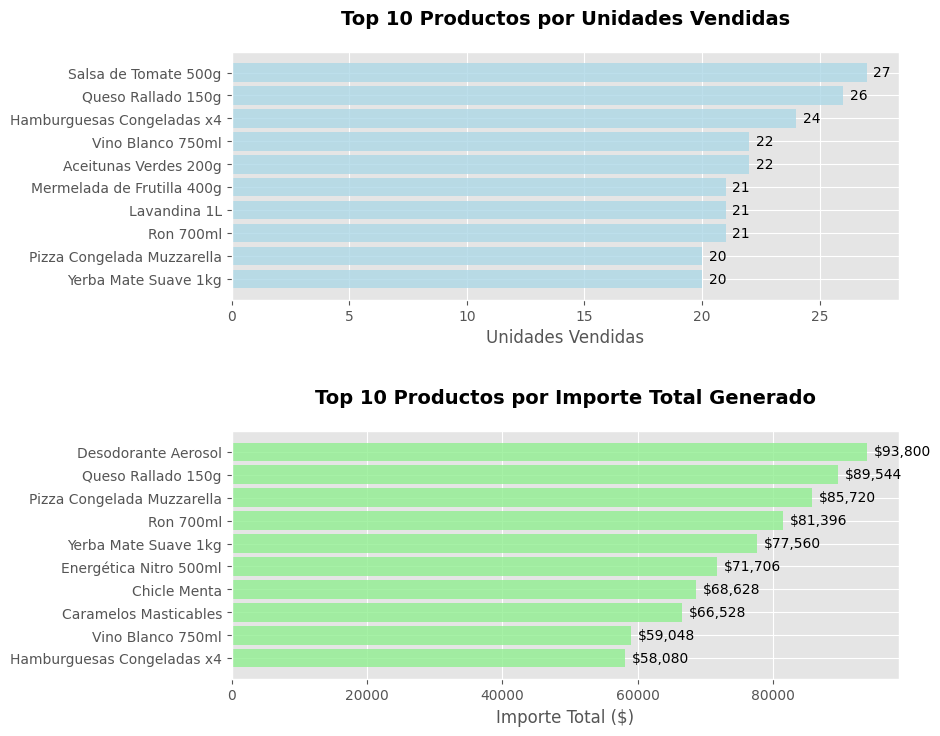

In [24]:

# TTop ten productos por unidades vendidas e importe total

# 1. Agregar las métricas a nivel de producto (sumando todos los meses)
#    Esto nos da el rendimiento total de cada producto.
metricas_totales_producto = metricas_producto.groupby(['nueva_categoria', 'nombre_producto']).agg({
    'unidades_vendidas': 'sum',
    'importe_total': 'sum'
}).reset_index()

# 2. Calcular los dos rankings "Top 10" de forma independiente
#    - Top 10 por unidades vendidas
top_10_unidades = metricas_totales_producto.nlargest(10, 'unidades_vendidas').sort_values('unidades_vendidas')
#    - Top 10 por importe total
top_10_importe = metricas_totales_producto.nlargest(10, 'importe_total').sort_values('importe_total')

# Configurar el estilo
plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

# --- Gráfico 1: Top 10 por Unidades Vendidas (con corrección en las etiquetas) ---
bars1 = ax1.barh(y=top_10_unidades['nombre_producto'], 
                 width=top_10_unidades['unidades_vendidas'],
                 color='lightblue', alpha=0.8)

ax1.set_title('Top 10 Productos por Unidades Vendidas', fontsize=14, pad=20, fontweight='bold')
ax1.set_xlabel('Unidades Vendidas', fontsize=12)

# Añadir valores en las barras con un offset dinámico y más pequeño

# 1. Obtenemos el límite derecho del eje X para calcular un offset proporcional.
x_max_unidades = ax1.get_xlim()[1]
offset_unidades = x_max_unidades * 0.01  # Usamos un 1% del ancho del gráfico como espacio.

for bar in bars1:
    width = bar.get_width()
    # 2. Aplicamos el nuevo offset dinámico en lugar de un valor fijo.
    ax1.text(width + offset_unidades, bar.get_y() + bar.get_height()/2,
             f'{width:,.0f}',
             va='center', fontsize=10)

# --- Gráfico 2: Top 10 por Importe Total ---
bars2 = ax2.barh(y=top_10_importe['nombre_producto'], 
                 width=top_10_importe['importe_total'],
                 color='lightgreen', alpha=0.8)

ax2.set_title('Top 10 Productos por Importe Total Generado', fontsize=14, pad=20, fontweight='bold')
ax2.set_xlabel('Importe Total ($)', fontsize=12)

# Aplicamos la misma lógica de offset dinámico para el segundo gráfico
x_max_importe = ax2.get_xlim()[1]
offset_importe = x_max_importe * 0.01

for bar in bars2:
    width = bar.get_width()
    ax2.text(width + offset_importe, bar.get_y() + bar.get_height()/2,
             f'${width:,.0f}',
             va='center', fontsize=10)

# --- Finalización del gráfico (sin cambios) ---
plt.tight_layout(pad=3.0)
plt.show()


### Análisis de Métricas de Ventas por Medio de Pago

In [25]:
# Crear reporte de ventas por medio de pago

metricas_generales = df_consolidado.groupby('medio_pago').agg(
    n_transacciones=('id_venta', 'nunique'),
    importe_total=('importe', 'sum'),
    n_clientes_unicos=('id_cliente', 'nunique'),
    unidades_vendidas=('cantidad', 'sum'), # Métrica más clara que 'count' de productos
    primera_venta=('fecha_venta', 'min'),
    ultima_venta=('fecha_venta', 'max')
)


# Calcular el importe total por cada transacción (id_venta)
# Esto es crucial para calcular el ticket promedio correctamente.
df_ventas_totales = df_consolidado.groupby(['id_venta', 'medio_pago']).agg(
    importe_por_venta=('importe', 'sum')
).reset_index()

# Calcular el ticket promedio y su desviación estándar a partir de las ventas totales.
# Ahora 'mean' y 'std' operan sobre el valor total de cada transacción.
metricas_ticket = df_ventas_totales.groupby('medio_pago').agg(
    ticket_promedio=('importe_por_venta', 'mean'),
    desviacion_estandar=('importe_por_venta', 'std')
)

# Unir los dos DataFrames de métricas en uno solo.
metricas_pago = metricas_generales.join(metricas_ticket)

# Reordenar las columnas para que coincidan con tu diseño original y redondear.
column_order = [
    'n_transacciones',
    'importe_total',
    'ticket_promedio',
    'desviacion_estandar',
    'n_clientes_unicos',
    'unidades_vendidas', # Nombre actualizado
    'primera_venta',
    'ultima_venta'
]
metricas_pago = metricas_pago[column_order].round(1)

# Ordenamos el reporte final por el número de transacciones de mayor a menor.
metricas_pago = metricas_pago.sort_values(by='n_transacciones', ascending=False)


In [26]:
metricas_pago.head()

,n_transacciones,importe_total,ticket_promedio,desviacion_estandar,n_clientes_unicos,unidades_vendidas,primera_venta,ultima_venta
medio_pago,,,,,,,,
efectivo,37,934819,25265.4,13174.4,30,345,2024-01-02,2024-06-28
qr,30,714280,23809.3,13646.5,24,266,2024-01-04,2024-06-28
transferencia,27,542219,20082.2,12759.5,24,218,2024-01-06,2024-06-27
tarjeta,26,460099,17696.1,13108.4,18,187,2024-01-13,2024-06-25


In [27]:
# Guardando metrica_pago en un archivo csv
metricas_pago.to_csv("metricas_pago.csv")

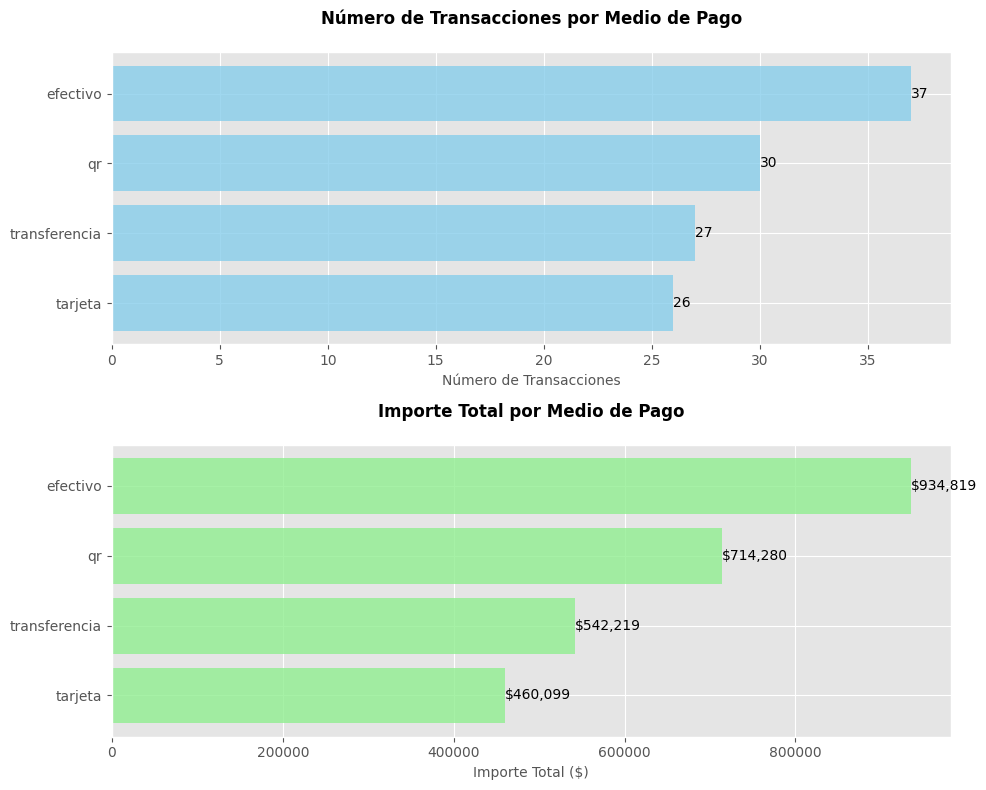

In [28]:
# 1. Gráfico de barras comparativo
plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Ordenar por número de transacciones
ventas_pago_sorted = metricas_pago.sort_values('n_transacciones', ascending=True)

# Gráfico de número de transacciones
bars1 = ax1.barh(range(len(ventas_pago_sorted)), ventas_pago_sorted['n_transacciones'],
                color='skyblue', alpha=0.8)

# Personalizar primer gráfico
ax1.set_title('Número de Transacciones por Medio de Pago', fontsize=12, pad=20, fontweight='bold')
ax1.set_xlabel('Número de Transacciones', fontsize=10)
ax1.set_yticks(range(len(ventas_pago_sorted)))
ax1.set_yticklabels(ventas_pago_sorted.index)

# Añadir valores en las barras
for bar in bars1:
    width = bar.get_width()
    ax1.text(width, bar.get_y() + bar.get_height()/2,
             f'{width:,.0f}',
             va='center', ha='left')

# Ordenar por importe total
ventas_pago_sorted = metricas_pago.sort_values('importe_total', ascending=True)

# Gráfico de importe total
bars2 = ax2.barh(range(len(ventas_pago_sorted)), ventas_pago_sorted['importe_total'],
                color='lightgreen', alpha=0.8)

# Personalizar segundo gráfico
ax2.set_title('Importe Total por Medio de Pago', fontsize=12, pad=20, fontweight='bold')
ax2.set_xlabel('Importe Total ($)', fontsize=10)
ax2.set_yticks(range(len(ventas_pago_sorted)))
ax2.set_yticklabels(ventas_pago_sorted.index)

# Añadir valores en las barras
for bar in bars2:
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2,
             f'${width:,.0f}',
             va='center', ha='left')

plt.tight_layout()
plt.show()

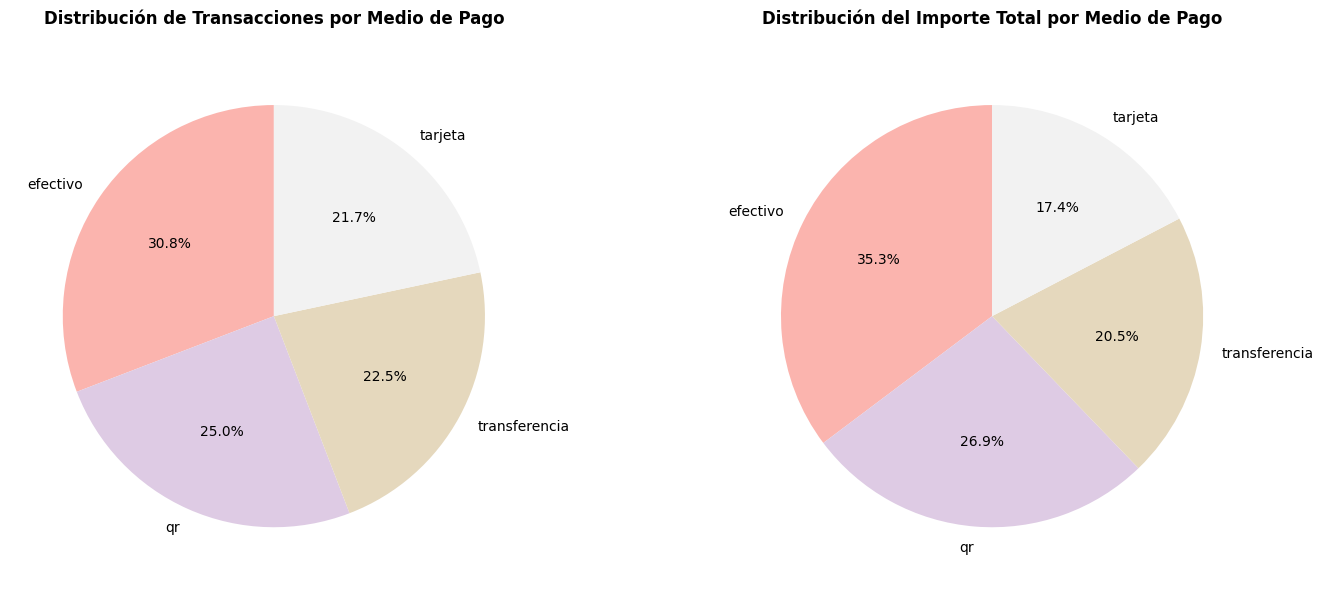


Distribución porcentual por medio de pago:
               Transacciones  % Transacciones  Importe Total  % Importe
medio_pago                                                             
efectivo                  37            30.83         934819      35.26
qr                        30            25.00         714280      26.94
transferencia             27            22.50         542219      20.45
tarjeta                   26            21.67         460099      17.35


In [29]:
# 2. Gráficos de pastel para distribución porcentual
plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Calcular porcentajes
total_transacciones = metricas_pago['n_transacciones'].sum()
total_importe = metricas_pago['importe_total'].sum()

# Gráfico de pastel para número de transacciones
wedges1, texts1, autotexts1 = ax1.pie(metricas_pago['n_transacciones'],
                                     labels=metricas_pago.index,
                                     autopct='%1.1f%%',
                                     startangle=90,
                                     colors=plt.cm.Pastel1(np.linspace(0, 1, len(metricas_pago))))
ax1.set_title('Distribución de Transacciones por Medio de Pago', fontsize=12, pad=20, fontweight='bold')

# Gráfico de pastel para importe total
wedges2, texts2, autotexts2 = ax2.pie(metricas_pago['importe_total'],
                                     labels=metricas_pago.index,
                                     autopct='%1.1f%%',
                                     startangle=90,
                                     colors=plt.cm.Pastel1(np.linspace(0, 1, len(metricas_pago))))
ax2.set_title('Distribución del Importe Total por Medio de Pago', fontsize=12, pad=20, fontweight='bold')

# Ajustar layout
plt.tight_layout()
plt.show()

# Mostrar tabla de resultados con porcentajes
print("\nDistribución porcentual por medio de pago:")
resultados = pd.DataFrame({
    'Transacciones': metricas_pago['n_transacciones'],
    '% Transacciones': (metricas_pago['n_transacciones'] / total_transacciones * 100).round(2),
    'Importe Total': metricas_pago['importe_total'],
    '% Importe': (metricas_pago['importe_total'] / total_importe * 100).round(2)
})
print(resultados)

C:\Users\capab\AppData\Local\Temp\ipykernel_18468\3594641222.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tickets_por_venta[tickets_por_venta['medio_pago'] == medio]['importe'] for medio in orden_medios],


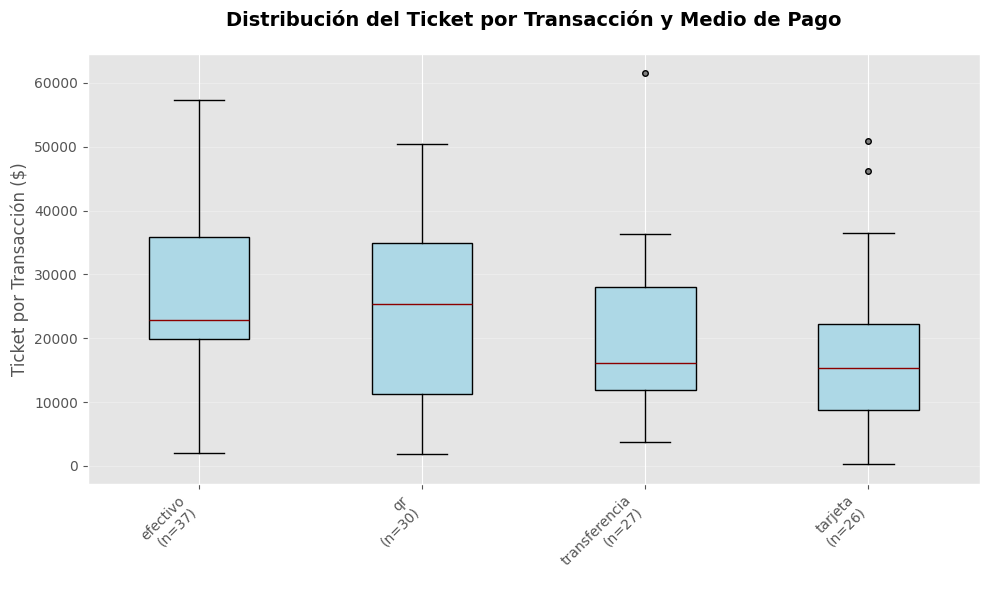


Estadísticas de tickets por medio de pago (ordenado por n° de transacciones):
               count      mean       std     min       25%      50%       75%  \
medio_pago                                                                      
efectivo        37.0  25265.38  13174.36  2012.0  19825.00  22851.0  35856.00   
qr              30.0  23809.33  13646.53  1876.0  11265.00  25318.5  34976.50   
transferencia   27.0  20082.19  12759.54  3827.0  11881.00  16053.0  28046.00   
tarjeta         26.0  17696.12  13108.42   272.0   8793.25  15411.5  22294.75   

                   max  
medio_pago              
efectivo       57287.0  
qr             50461.0  
transferencia  61503.0  
tarjeta        50855.0  


In [30]:
# Boxplot de ticket promedio por transacción única y medio de pago, ordenando los medios de pago por número de transacciones

# --- Paso 1: Calcular el ticket por cada transacción única ---
tickets_por_venta = df_consolidado.groupby(['id_venta', 'medio_pago'], as_index=False)['importe'].sum()

# --- Paso 2: Determinar el orden de los medios de pago por n° de transacciones ---
orden_medios = tickets_por_venta['medio_pago'].value_counts().index.tolist()

# --- Paso 3: Generar el gráfico Boxplot con Matplotlib ---
plt.style.use('ggplot')
plt.figure(figsize=(10, 6))

# Creas el boxplot iterando sobre tu lista 'orden_medios', lo que asegura el orden correcto.
plt.boxplot([tickets_por_venta[tickets_por_venta['medio_pago'] == medio]['importe'] for medio in orden_medios],
            labels=[f"{medio}\n(n={tickets_por_venta['medio_pago'].value_counts()[medio]})" for medio in orden_medios],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='black'),
            medianprops=dict(color='darkred'),
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=4))

# --- Paso 4: Personalizar y mostrar el gráfico ---
plt.title('Distribución del Ticket por Transacción y Medio de Pago', fontsize=14, pad=20, fontweight='bold')
plt.ylabel('Ticket por Transacción ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Paso 5: Mostrar estadísticas descriptivas ---
print("\nEstadísticas de tickets por medio de pago (ordenado por n° de transacciones):")
stats_tickets = tickets_por_venta.groupby('medio_pago')['importe'].describe().round(2)
print(stats_tickets.loc[orden_medios])

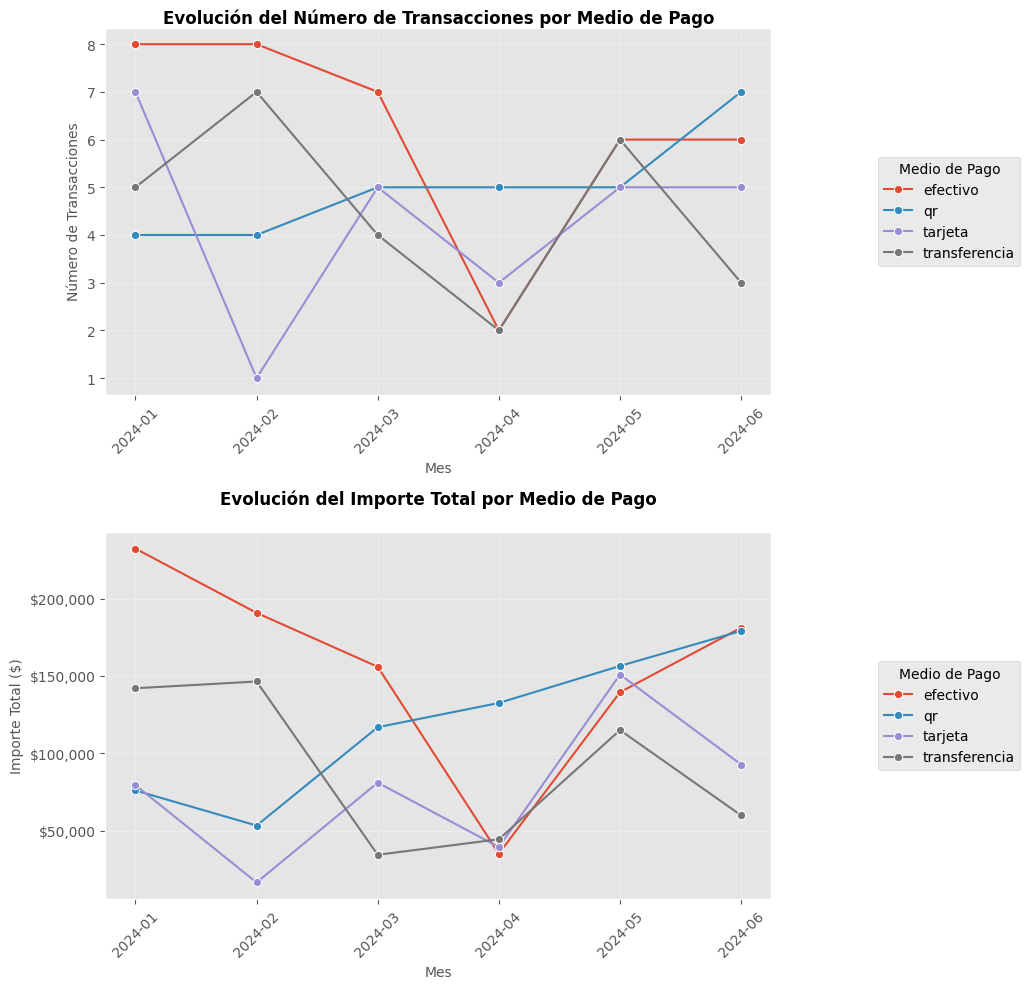


Estadísticas mensuales por medio de pago:

Número de transacciones por mes:
fecha_venta    2024-01  2024-02  2024-03  2024-04  2024-05  2024-06
medio_pago                                                         
efectivo             8        8        7        2        6        6
qr                   4        4        5        5        5        7
tarjeta              7        1        5        3        5        5
transferencia        5        7        4        2        6        3

Importe total por mes:
fecha_venta    2024-01  2024-02  2024-03  2024-04  2024-05  2024-06
medio_pago                                                         
efectivo        232324   190787   155927    35112   139484   181185
qr               76000    53298   116883   132538   156459   179102
tarjeta          79462    16531    81038    39428   150892    92748
transferencia   142054   146425    34415    44446   114997    59882


In [31]:
# 4. Evolución temporal de medios de pago

# Agrupar datos por mes y medio de pago
evolucion_pagos = df_consolidado.groupby([df_consolidado['fecha_venta'].dt.strftime('%Y-%m'), 'medio_pago']).agg({
    'id_venta': 'nunique',
    'importe': 'sum'
}).reset_index()

# Crear visualizaciones
plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Gráfico de evolución de número de transacciones
sns.lineplot(data=evolucion_pagos, x='fecha_venta', y='id_venta',
             hue='medio_pago', marker='o', ax=ax1)

# Personalizar primer gráfico
ax1.set_title('Evolución del Número de Transacciones por Medio de Pago', fontsize=12, pad=2, fontweight='bold')
ax1.set_xlabel('Mes', fontsize=10)
ax1.set_ylabel('Número de Transacciones', fontsize=10)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)
ax1.legend(title='Medio de Pago', bbox_to_anchor=(1.15, 0.5), loc='center left')

# Gráfico de evolución de importe total
sns.lineplot(data=evolucion_pagos, x='fecha_venta', y='importe',
             hue='medio_pago', marker='o', ax=ax2)

# Personalizar segundo gráfico
ax2.set_title('Evolución del Importe Total por Medio de Pago', fontsize=12, pad=20, fontweight='bold')
ax2.set_xlabel('Mes', fontsize=10)
ax2.set_ylabel('Importe Total ($)', fontsize=10)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)
ax2.legend(title='Medio de Pago', bbox_to_anchor=(1.15, 0.5), loc='center left')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Ajustar layout
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

# Mostrar estadísticas por mes
print("\nEstadísticas mensuales por medio de pago:")
stats_mensuales = evolucion_pagos.pivot_table(
    index='medio_pago',
    columns='fecha_venta',
    values=['id_venta', 'importe'],
    aggfunc='sum'
).round(2)

print("\nNúmero de transacciones por mes:")
print(stats_mensuales['id_venta'])
print("\nImporte total por mes:")
print(stats_mensuales['importe'])

### Análisis de Métricas de Ventas por Ciudad



In [32]:
# Crear DataFrame de ventas por ciudad

# --- Paso 1: Crear el reporte con una sola operación de agregación ---
metricas_ciudad = df_consolidado.groupby('ciudad').agg(
    num_transacciones=('id_venta', 'nunique'),
    importe_total=('importe', 'sum'),
    num_clientes=('id_cliente', 'nunique')
)

# --- Paso 2: Calcular métricas derivadas ---
metricas_ciudad['ticket_promedio'] = metricas_ciudad['importe_total'] / metricas_ciudad['num_transacciones']

# --- Paso 3: Ordenar el DataFrame ---
metricas_ciudad = metricas_ciudad.sort_values('importe_total', ascending=False)

# --- Paso 4: Calcular porcentajes sobre el total ---
total_ventas = metricas_ciudad['importe_total'].sum()
total_clientes = metricas_ciudad['num_clientes'].sum()
metricas_ciudad['porcentaje_ventas'] = (metricas_ciudad['importe_total'] / total_ventas * 100)
metricas_ciudad['porcentaje_clientes'] = (metricas_ciudad['num_clientes'] / total_clientes * 100)

# --- Paso 5: Formatear y redondear al final ---
metricas_ciudad = metricas_ciudad.round(1)

# --- Paso 6: Mostrar el DataFrame y las estadísticas ---
print("Análisis de Ventas por Ciudad:")
print("-" * 100)
print(metricas_ciudad)

# Mostrar estadísticas generales (tu código para esto ya es excelente)
print("\nEstadísticas Generales:")
print(f"Número total de ciudades: {len(metricas_ciudad)}")
print(f"Ciudad con mayor volumen de ventas: {metricas_ciudad.index[0]} (${metricas_ciudad['importe_total'].iloc[0]:,.2f})")
print(f"Ciudad con ticket promedio más alto: {metricas_ciudad['ticket_promedio'].idxmax()} (${metricas_ciudad['ticket_promedio'].max():,.2f})")
print(f"Ciudad con más clientes únicos: {metricas_ciudad['num_clientes'].idxmax()} ({metricas_ciudad['num_clientes'].max():,} clientes)")

Análisis de Ventas por Ciudad:
----------------------------------------------------------------------------------------------------
             num_transacciones  importe_total  num_clientes  ticket_promedio  \
ciudad                                                                         
Rio Cuarto                  37         792203            18          21410.9   
Alta Gracia                 25         481504            14          19260.2   
Cordoba                     24         481482            11          20061.8   
Carlos Paz                  13         353852             9          27219.4   
Villa Maria                 11         313350             8          28486.4   
Mendiolaza                  10         229026             7          22902.6   

             porcentaje_ventas  porcentaje_clientes  
ciudad                                               
Rio Cuarto                29.9                 26.9  
Alta Gracia               18.2                 20.9  
Cordoba    

In [33]:
metricas_ciudad.head(6)

,num_transacciones,importe_total,num_clientes,ticket_promedio,porcentaje_ventas,porcentaje_clientes
ciudad,,,,,,
Rio Cuarto,37,792203,18,21410.9,29.9,26.9
Alta Gracia,25,481504,14,19260.2,18.2,20.9
Cordoba,24,481482,11,20061.8,18.2,16.4
Carlos Paz,13,353852,9,27219.4,13.3,13.4
Villa Maria,11,313350,8,28486.4,11.8,11.9
Mendiolaza,10,229026,7,22902.6,8.6,10.4


In [34]:
metricas_ciudad.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, Rio Cuarto to Mendiolaza
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   num_transacciones    6 non-null      int64  
 1   importe_total        6 non-null      int64  
 2   num_clientes         6 non-null      int64  
 3   ticket_promedio      6 non-null      float64
 4   porcentaje_ventas    6 non-null      float64
 5   porcentaje_clientes  6 non-null      float64
dtypes: float64(3), int64(3)
memory usage: 336.0+ bytes


In [35]:
# Guardando metricas_ciudad en un archivo csv
metricas_ciudad.to_csv("metricas_ciudad.csv")

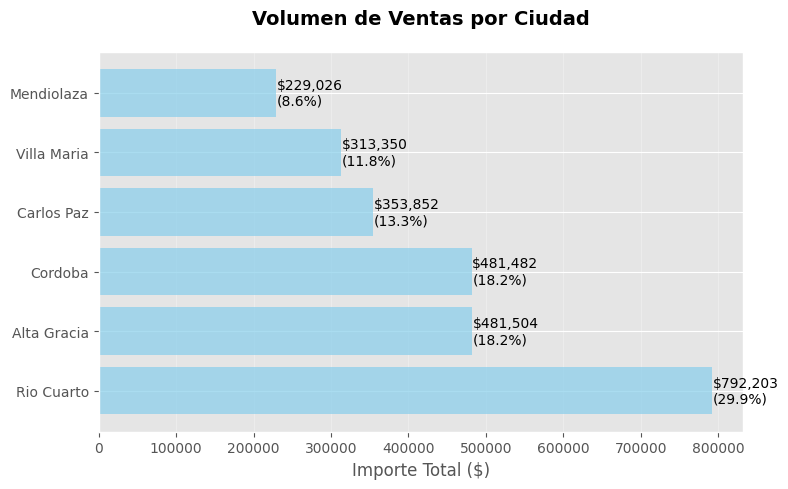

In [36]:
# 1. Gráfico de barras horizontal de las ciudades por importe total

plt.figure(figsize=(8, 5))

# Crear gráfico de barras horizontal
bars = plt.barh(metricas_ciudad.index, metricas_ciudad['importe_total'], 
                color='skyblue', alpha=0.7)

# Añadir etiquetas con valores y porcentajes
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 1000, i, f'${width:,.0f}\n({metricas_ciudad["porcentaje_ventas"].iloc[i]:.1f}%)',
             va='center', fontsize=10)

plt.title('Volumen de Ventas por Ciudad', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Importe Total ($)', fontsize=12)

plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

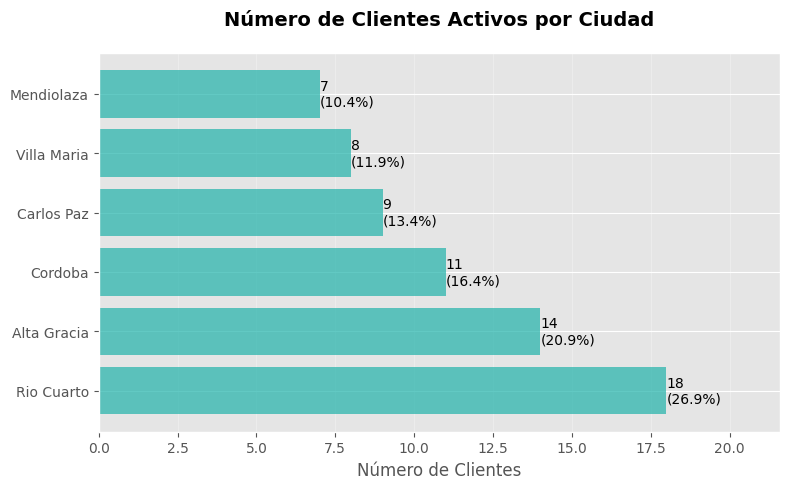

In [37]:
# 2. Gráfico de número de clientes activos por ciudad

plt.figure(figsize=(8, 5))

# Preparar datos de clientes activos por ciudad
clientes_activos = metricas_ciudad['num_clientes'].sort_values(ascending=False)

# Crear gráfico de barras horizontal
bars = plt.barh(np.arange(len(clientes_activos)), clientes_activos,
                color='lightseagreen', alpha=0.7)

# Añadir etiquetas de valor
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{int(width):,}\n({metricas_ciudad["porcentaje_clientes"].iloc[i]:.1f}%)',
             ha='left', 
             va='center', fontsize=10)
    
# Personalizar el gráfico
plt.title('Número de Clientes Activos por Ciudad', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Número de Clientes', fontsize=12)
plt.yticks(np.arange(len(clientes_activos)), clientes_activos.index)

# Añadir grid vertical para mejor lectura
plt.grid(True, axis='x', alpha=0.3)

# Ajustar márgenes
plt.margins(x=0.2)
plt.tight_layout()
plt.show()

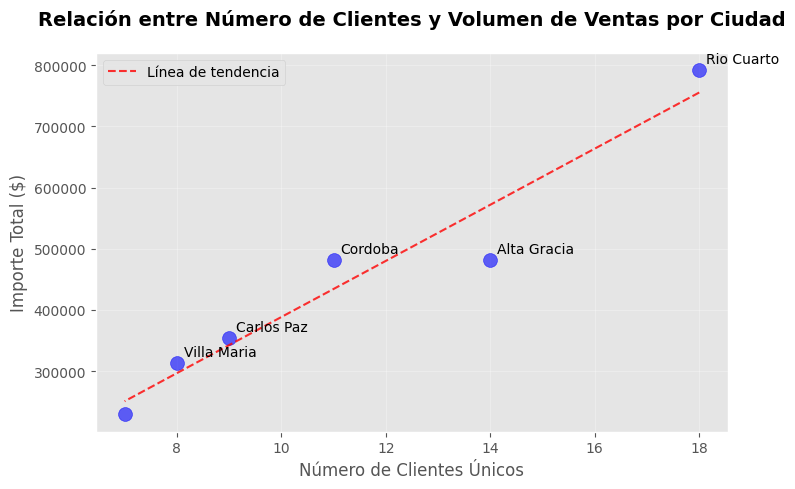

In [38]:
# 3. Scatter plot: Relación entre número de clientes y volumen de ventas
plt.figure(figsize=(8, 5))

# Crear scatter plot
plt.scatter(metricas_ciudad['num_clientes'], metricas_ciudad['importe_total'],
           alpha=0.6, s=100, c='blue')

# Añadir etiquetas para las top 5 ciudades
top_5_ciudades = metricas_ciudad.head()
for idx in top_5_ciudades.index:
    plt.annotate(idx, 
                (metricas_ciudad.loc[idx, 'num_clientes'], metricas_ciudad.loc[idx, 'importe_total']),
                xytext=(5, 5), textcoords='offset points')

plt.title('Relación entre Número de Clientes y Volumen de Ventas por Ciudad', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Número de Clientes Únicos', fontsize=12)
plt.ylabel('Importe Total ($)', fontsize=12)

# Añadir línea de tendencia
z = np.polyfit(metricas_ciudad['num_clientes'], metricas_ciudad['importe_total'], 1)
p = np.poly1d(z)
plt.plot(metricas_ciudad['num_clientes'], p(metricas_ciudad['num_clientes']), 
         "r--", alpha=0.8, label='Línea de tendencia')

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\capab\AppData\Local\Temp\ipykernel_18468\3690648038.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tickets_por_ciudad[tickets_por_ciudad['ciudad'] == ciudad]['importe']


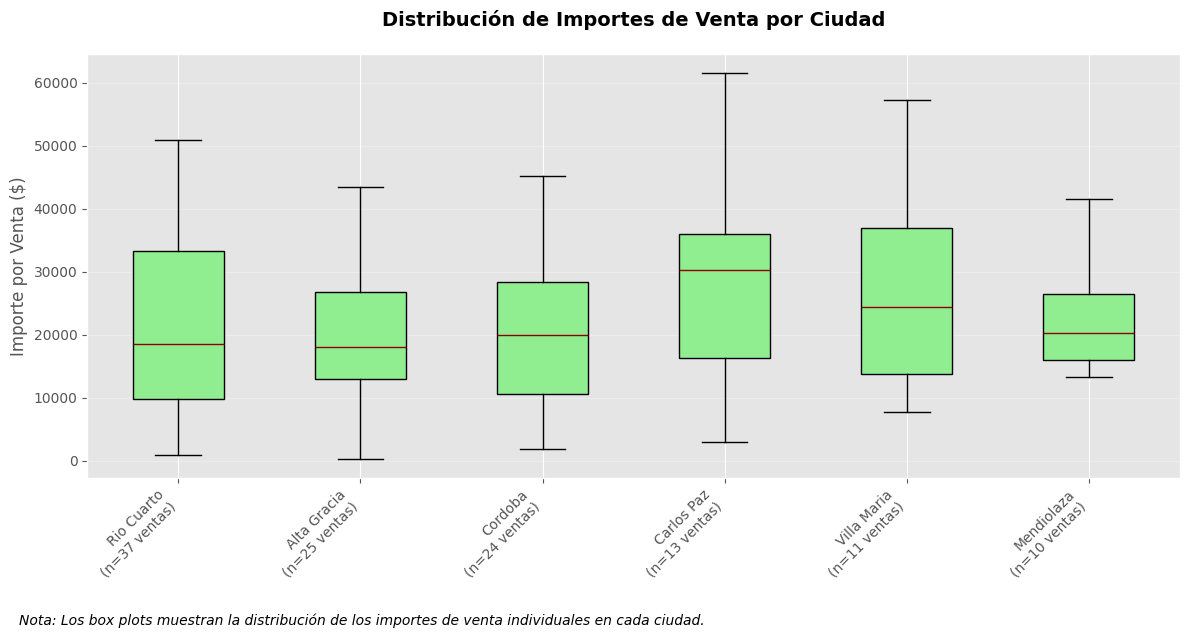

In [39]:
# 4. Box plot de distribución de importes de venta por ciudad
plt.figure(figsize=(12, 6))

# Preparar datos para el box plot
tickets_por_ciudad = df_consolidado.groupby(['ciudad', 'id_venta'])['importe'].sum().reset_index()
todas_ciudades = metricas_ciudad.index

# Crear box plot
plt.boxplot([tickets_por_ciudad[tickets_por_ciudad['ciudad'] == ciudad]['importe'] 
             for ciudad in todas_ciudades],
            labels=[f"{ciudad}\n(n={len(tickets_por_ciudad[tickets_por_ciudad['ciudad'] == ciudad])} ventas)"
                    for ciudad in todas_ciudades],
            patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='black'),
            medianprops=dict(color='darkred'),
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=4))

plt.title('Distribución de Importes de Venta por Ciudad', fontsize=14, pad=20, fontweight='bold')
plt.ylabel('Importe por Venta ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', alpha=0.3)

# Añadir una nota explicativa
plt.figtext(0.02, -0.05, 'Nota: Los box plots muestran la distribución de los importes de venta individuales en cada ciudad.', 
            fontsize=10, style='italic')

plt.tight_layout()
plt.show()

# Segmentación de Clientes

Realizaremos una segmentación simple basada en:
1. Valor del cliente (importe_total)
2. Frecuencia de compra
3. Ticket promedio

Esto nos permitirá clasificar a los clientes en categorías fácilmente interpretables.

In [117]:
# Criterios de segmentación de clientes

# Crear una copia del DataFrame para la segmentación
clientes_segmentados = metricas_cliente.copy()

# Definir límites de manera más completa
limite_valor_alto = clientes_segmentados['importe_total'].quantile(0.75)
limite_valor_medio = clientes_segmentados['importe_total'].quantile(0.50)


limite_frecuencia_alta = clientes_segmentados['frecuencia_compra'].quantile(0.75)
limite_frecuencia_baja = clientes_segmentados['frecuencia_compra'].quantile(0.25) # Límite añadido

limite_ticket_alto = clientes_segmentados['ticket_promedio'].quantile(0.75)
limite_ticket_medio = clientes_segmentados['ticket_promedio'].quantile(0.50) # Límite añadido

# Crear las categorías de valor
clientes_segmentados['categoria_valor'] = pd.cut(
    clientes_segmentados['importe_total'],
    bins=[-float('inf'), limite_valor_medio, limite_valor_alto, float('inf')],
    labels=['Valor Bajo', 'Valor Medio', 'Valor Alto']
)

# Crear categorías de frecuencia equilibradas (incorrecto)
# clientes_segmentados['categoria_frecuencia'] = pd.cut(
#    clientes_segmentados['frecuencia_compra'],
#    bins=[0, limite_frecuencia_baja, limite_frecuencia_alta, float('inf')],
#    labels=['Ocasional', 'Regular', 'Frecuente'],
#    right=True # Asegura que el límite superior se incluye en el intervalo
#)

# Crear categorías de frecuencia (CORREGIDO)
# Se invierten las etiquetas para que un valor bajo de 'frecuencia_compra' 
# (más frecuente) se asigne a la etiqueta 'Frecuente'.
clientes_segmentados['categoria_frecuencia'] = pd.cut(
    clientes_segmentados['frecuencia_compra'],
    bins=[0, limite_frecuencia_baja, limite_frecuencia_alta, float('inf')],
    labels=['Frecuente', 'Regular', 'Ocasional'], # <-- ETIQUETAS CORREGIDAS
    right=True 
)

# Crear categorías de ticket con 3 niveles
clientes_segmentados['categoria_ticket'] = pd.cut(
    clientes_segmentados['ticket_promedio'],
    bins=[-float('inf'), limite_ticket_medio, limite_ticket_alto, float('inf')],
    labels=['Ticket Bajo', 'Ticket Medio', 'Ticket Alto']
)

# Definir segmentos de clientes
def asignar_segmento(row):
    if row['categoria_valor'] == 'Valor Alto' and row['categoria_frecuencia'] == 'Frecuente':
        return 'VIP'
    elif row['categoria_valor'] == 'Valor Alto' or (row['categoria_frecuencia'] == 'Frecuente' and row['categoria_ticket'] == 'Ticket Alto'):
        return 'Premium'
    elif row['categoria_valor'] == 'Valor Medio' or row['categoria_frecuencia'] == 'Regular':
        return 'Regular'
    else:
        return 'Básico'

clientes_segmentados['segmento'] = clientes_segmentados.apply(asignar_segmento, axis=1)

# Mostrar resumen de segmentación
print("Resumen de Criterios de Segmentación:")
print("-" * 50)


print("\nDistribución por Segmento:")
print(clientes_segmentados['segmento'].value_counts())

# Calcular métricas por segmento con .agg() ---
stats_segmentos = clientes_segmentados.groupby('segmento').agg(
    Numero_de_Clientes=('importe_total', 'count'),
    Importe_Total=('importe_total', 'sum'),
    Frecuencia_Promedio=('frecuencia_compra', 'mean'),
    Ticket_Promedio=('ticket_promedio', 'mean')
).round(2)

# Calcular porcentaje de ingresos por segmento
total_ingresos = stats_segmentos['Importe_Total'].sum()
stats_segmentos['Porcentaje_Ingresos'] = (stats_segmentos['Importe_Total'] / total_ingresos * 100).round(2)

print("\nEstadísticas por Segmento:")
print(stats_segmentos)

Resumen de Criterios de Segmentación:
--------------------------------------------------

Distribución por Segmento:
segmento
Básico     29
Regular    21
Premium    13
VIP         4
Name: count, dtype: int64

Estadísticas por Segmento:
          Numero_de_Clientes  Importe_Total  Frecuencia_Promedio  \
segmento                                                           
Básico                    29         618135                61.50   
Premium                   13         936935                59.90   
Regular                   21         798970                44.75   
VIP                        4         297377                12.75   

          Ticket_Promedio  Porcentaje_Ingresos  
segmento                                        
Básico           17573.53                23.31  
Premium          32314.35                35.34  
Regular          25208.30                30.13  
VIP              28942.80                11.22  


## Criterios de Segmentación

Los clientes se clasifican en cuatro segmentos según su comportamiento de compra:

1. **VIP**: 
   - Alto valor total de compras (top 25%)
   - Alta frecuencia de compra (top 25%)

2. **Premium**:
   - Alto valor total de compras (top 25%) O
   - Combinación de alta frecuencia y ticket alto

3. **Regular**:
   - Valor medio de compras O
   - Frecuencia regular de compra

4. **Básico**:
   - Valor bajo de compras
   - Baja frecuencia de compra

In [118]:
# Verificación de totales
print("Verificación de totales:")
print("-" * 50)

# Total del consolidado
total_consolidado = df_consolidado['importe'].sum()
print(f"Total en df_consolidado: ${total_consolidado:,.2f}")

# Total de métricas_cliente
total_metricas = metricas_cliente['importe_total'].sum()
print(f"Total en metricas_cliente: ${total_metricas:,.2f}")

# Total por segmentos
total_segmentos = stats_segmentos['Importe_Total'].sum()
print(f"Total en segmentación: ${total_segmentos:,.2f}")

# Verificar si hay diferencias usando una tolerancia para el redondeo
if not np.isclose(total_consolidado, total_metricas) or not np.isclose(total_metricas, total_segmentos):
    print("\n¡Atención! Hay diferencias significativas en los totales.")
    print("\nDiferencias:")
    print(f"Consolidado vs Métricas: ${total_consolidado - total_metricas:,.2f}")
    print(f"Métricas vs Segmentos: ${total_metricas - total_segmentos:,.2f}")
else:
    print("\nLos totales coinciden correctamente en todas las tablas (considerando el redondeo).")

Verificación de totales:
--------------------------------------------------
Total en df_consolidado: $2,651,417.00
Total en metricas_cliente: $2,651,417.00
Total en segmentación: $2,651,417.00

Los totales coinciden correctamente en todas las tablas (considerando el redondeo).


C:\Users\capab\AppData\Local\Temp\ipykernel_18468\1273593979.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clientes_segmentados, x='segmento',
C:\Users\capab\AppData\Local\Temp\ipykernel_18468\1273593979.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clientes_segmentados, x='segmento', y='ticket_promedio',


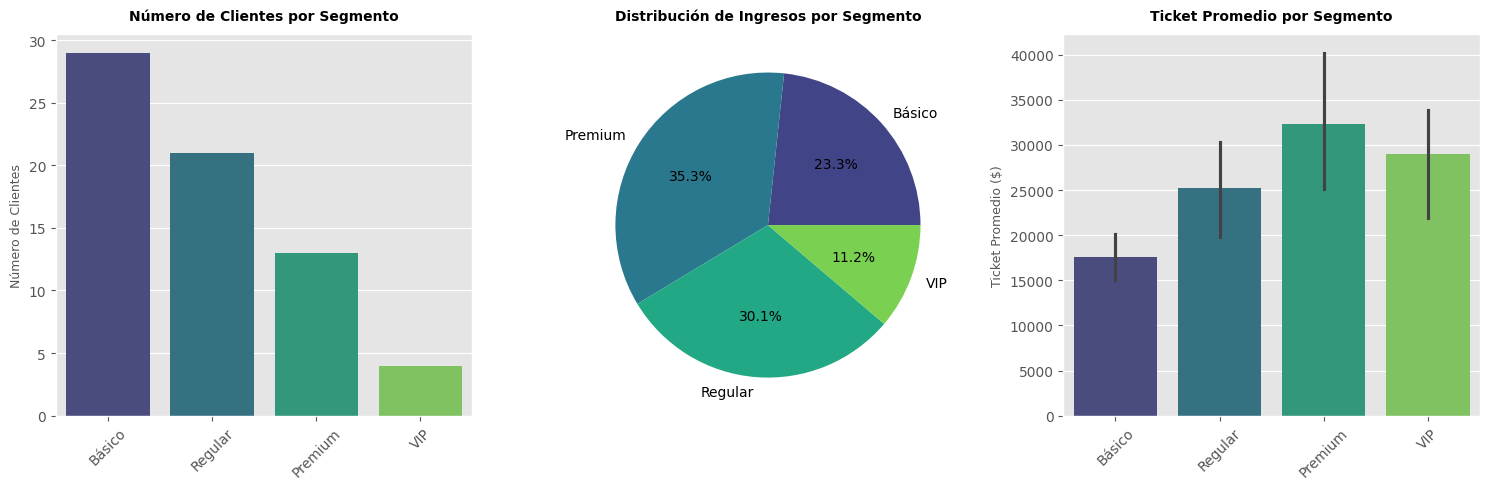


Características típicas por segmento:
--------------------------------------------------

Segmento Premium:
- Número de clientes: 13
- Importe total: $936,935.00
- Frecuencia de compra promedio: 59.90
- Ticket promedio: $32,314.35
- Contribución a ingresos: 35.3%

Segmento Básico:
- Número de clientes: 29
- Importe total: $618,135.00
- Frecuencia de compra promedio: 61.50
- Ticket promedio: $17,573.53
- Contribución a ingresos: 23.3%

Segmento Regular:
- Número de clientes: 21
- Importe total: $798,970.00
- Frecuencia de compra promedio: 44.75
- Ticket promedio: $25,208.30
- Contribución a ingresos: 30.1%

Segmento VIP:
- Número de clientes: 4
- Importe total: $297,377.00
- Frecuencia de compra promedio: 12.75
- Ticket promedio: $28,942.80
- Contribución a ingresos: 11.2%


In [119]:
# Visualizar la distribución de segmentos
plt.figure(figsize=(15, 5))

# 1. Gráfico de barras para número de clientes por segmento
plt.subplot(131)
sns.countplot(data=clientes_segmentados, x='segmento', 
              order=clientes_segmentados['segmento'].value_counts().index,
              palette='viridis')
plt.title('Número de Clientes por Segmento', fontsize=10,  pad=10, fontweight='bold')
plt.ylabel('Número de Clientes', fontsize=9)
plt.xlabel(None)
plt.xticks(rotation=45)

# 2. Gráfico de torta para distribución de ingresos por segmento
plt.subplot(132)
plt.pie(stats_segmentos['Porcentaje_Ingresos'], labels=stats_segmentos.index, autopct='%1.1f%%',
        colors=sns.color_palette('viridis', n_colors=len(stats_segmentos)))
plt.title('Distribución de Ingresos por Segmento', fontsize=10,  pad=10, fontweight='bold')

# 3. Gráfico de barras para ticket promedio por segmento
plt.subplot(133)
sns.barplot(data=clientes_segmentados, x='segmento', y='ticket_promedio',
           order=clientes_segmentados['segmento'].value_counts().index,
           palette='viridis')
plt.title('Ticket Promedio por Segmento', fontsize=10,  pad=10, fontweight='bold')
plt.ylabel('Ticket Promedio ($)', fontsize=9)
plt.xlabel(None)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Mostrar características típicas de cada segmento
print("\nCaracterísticas típicas por segmento:")
print("-" * 50)
for segmento in clientes_segmentados['segmento'].unique():
    datos_segmento = clientes_segmentados[clientes_segmentados['segmento'] == segmento]
    print(f"\nSegmento {segmento}:")
    print(f"- Número de clientes: {len(datos_segmento)}")
    print(f"- Importe total: ${datos_segmento['importe_total'].sum():,.2f}")
    print(f"- Frecuencia de compra promedio: {datos_segmento['frecuencia_compra'].mean():.2f}")
    print(f"- Ticket promedio: ${datos_segmento['ticket_promedio'].mean():,.2f}")
    print(f"- Contribución a ingresos: {stats_segmentos.loc[segmento, 'Porcentaje_Ingresos']:.1f}%")

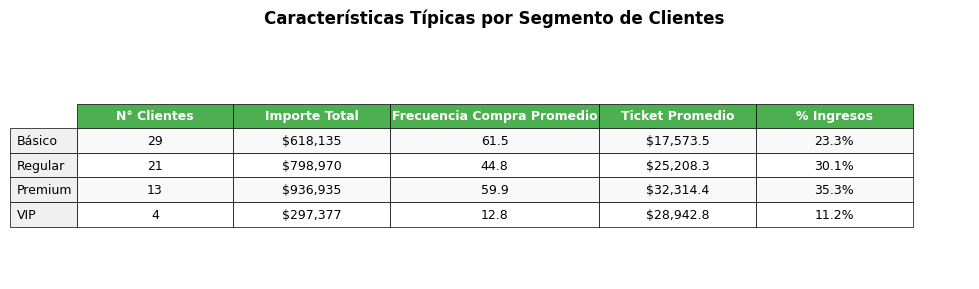

In [120]:
# Crear un DataFrame con las características típicas por segmento
caracteristicas_segmentos = pd.DataFrame()

for segmento in clientes_segmentados['segmento'].unique():
    datos_segmento = clientes_segmentados[clientes_segmentados['segmento'] == segmento]
    caracteristicas_segmentos.loc[segmento, 'N° Clientes'] = len(datos_segmento)
    caracteristicas_segmentos.loc[segmento, 'Importe Total'] = datos_segmento['importe_total'].sum()  # Cambiado a sum()
    caracteristicas_segmentos.loc[segmento, 'Frecuencia Compra Promedio'] = datos_segmento['frecuencia_compra'].mean()
    caracteristicas_segmentos.loc[segmento, 'Ticket Promedio'] = datos_segmento['ticket_promedio'].mean()
    caracteristicas_segmentos.loc[segmento, '% Ingresos'] = stats_segmentos.loc[segmento, 'Porcentaje_Ingresos']

# Ordenar los segmentos por Importe Total
caracteristicas_segmentos = caracteristicas_segmentos.sort_values('N° Clientes', ascending=False)

# Formatear las columnas numéricas
caracteristicas_segmentos['N° Clientes'] = caracteristicas_segmentos['N° Clientes'].map(lambda x: f"{x:,.0f}")
caracteristicas_segmentos['Importe Total'] = caracteristicas_segmentos['Importe Total'].map(lambda x: f"${x:,.0f}")
caracteristicas_segmentos['Frecuencia Compra Promedio'] = caracteristicas_segmentos['Frecuencia Compra Promedio'].map(lambda x: f"{x:.1f}")
caracteristicas_segmentos['Ticket Promedio'] = caracteristicas_segmentos['Ticket Promedio'].map(lambda x: f"${x:,.1f}")
caracteristicas_segmentos['% Ingresos'] = caracteristicas_segmentos['% Ingresos'].map(lambda x: f"{x:.1f}%")

# Crear una figura y tabla con colores alternados
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')

# Crear tabla con anchos de columna personalizados
tabla = ax.table(cellText=caracteristicas_segmentos.values,
                rowLabels=caracteristicas_segmentos.index,
                colLabels=caracteristicas_segmentos.columns,
                cellLoc='center',
                loc='center',
                colWidths=[0.15, 0.15, 0.20, 0.15, 0.15])

# Dar formato a la tabla
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1.1, 1.5)

# Dar formato a los encabezados
for i in range(len(caracteristicas_segmentos.columns)):
    tabla[(0, i)].set_facecolor('#4CAF50')
    tabla[(0, i)].set_text_props(color='white', weight='bold')

# Dar formato a las etiquetas de filas
for i in range(len(caracteristicas_segmentos)):
    tabla[(i+1, -1)].set_facecolor('#f0f0f0')
    for j in range(len(caracteristicas_segmentos.columns)):
        tabla[(i+1, j)].set_facecolor('#f9f9f9' if i%2==0 else 'white')

plt.title('Características Típicas por Segmento de Clientes', pad=20, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [121]:
clientes_segmentados.head()


,nombre_cliente,email,ciudad,total_compras,importe_total,ticket_promedio,primera_compra,ultima_compra,dias_entre_compras,frecuencia_compra,productos_diferentes,categorias_diferentes,categoria_valor,categoria_frecuencia,categoria_ticket,segmento
id_cliente,,,,,,,,,,,,,,,,
1,Mariana Lopez,mariana.lopez@mail.com,Carlos Paz,2,72448,36224.0,2024-02-06,2024-03-26,49,49.0,9,5,Valor Alto,Regular,Ticket Alto,Premium
2,Nicolas Rojas,nicolas.rojas@mail.com,Carlos Paz,1,22150,22150.0,2024-04-12,2024-04-12,0,NaN,1,1,Valor Bajo,NaN,Ticket Medio,Básico
3,Hernan Martinez,hernan.martinez@mail.com,Rio Cuarto,1,33310,33310.0,2024-02-16,2024-02-16,0,NaN,4,2,Valor Bajo,NaN,Ticket Alto,Básico
5,Agustina Flores,agustina.flores@mail.com,Cordoba,4,132158,33039.5,2024-03-05,2024-06-25,112,37.3,13,3,Valor Alto,Regular,Ticket Alto,Premium
6,Uma Medina,uma.medina@mail.com,Villa Maria,2,48878,24439.0,2024-01-24,2024-02-13,20,20.0,7,3,Valor Medio,Frecuente,Ticket Medio,Regular


In [122]:
clientes_segmentados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67 entries, 1 to 100
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   nombre_cliente         67 non-null     object        
 1   email                  67 non-null     object        
 2   ciudad                 67 non-null     object        
 3   total_compras          67 non-null     int64         
 4   importe_total          67 non-null     int64         
 5   ticket_promedio        67 non-null     float64       
 6   primera_compra         67 non-null     datetime64[ns]
 7   ultima_compra          67 non-null     datetime64[ns]
 8   dias_entre_compras     67 non-null     int64         
 9   frecuencia_compra      37 non-null     float64       
 10  productos_diferentes   67 non-null     int64         
 11  categorias_diferentes  67 non-null     int64         
 12  categoria_valor        67 non-null     category      
 13  categoria_f

In [123]:
# Guardando clientes_segmentados en un archivo csv

clientes_segmentados.to_csv("clientes_segmentados.csv")

In [124]:
# Creando la columna id_cliente en clientes_segmentados para hacer el merge
clientes_segmentados = clientes_segmentados.reset_index()

# Unir la segmentación de clientes con el DataFrame consolidado
df_consolidado_segmentado = df_consolidado.merge(
    clientes_segmentados[['id_cliente', 'segmento']],
    on='id_cliente',
    how='left'
)


In [103]:
df_consolidado_segmentado.head()

,id_venta,fecha_venta,id_cliente,nombre_cliente,email,medio_pago,id_producto,nombre_producto,cantidad,precio_unitario,importe,categoria_corregida,nueva_categoria,ciudad,fecha_alta,mes_venta,segmento
0,1,2024-06-19,62,Guadalupe Romero,guadalupe.romero@mail.com,tarjeta,90,Toallas Húmedas x50,1,2902,2902,Limpieza,Limpieza,Carlos Paz,2023-03-03,2024-06,Regular
1,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr,82,Aceitunas Negras 200g,5,2394,11970,Alimentos,Alimentos,Rio Cuarto,2023-02-18,2024-03,VIP
2,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr,39,Helado Vainilla 1L,5,469,2345,Alimentos,Alimentos,Rio Cuarto,2023-02-18,2024-03,VIP
3,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr,70,Fernet 750ml,2,4061,8122,Alimentos,Bebidas_Alcoholicas,Rio Cuarto,2023-02-18,2024-03,VIP
4,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr,22,Medialunas de Manteca,1,2069,2069,Alimentos,Alimentos,Rio Cuarto,2023-02-18,2024-03,VIP


In [125]:
# Eliminado categoria_corregida en df_consolidado_segmentado

df_consolidado_segmentado = df_consolidado_segmentado.drop(columns=['categoria_corregida'])

In [127]:
df_consolidado_segmentado.head()

,id_venta,fecha_venta,id_cliente,nombre_cliente,email,medio_pago,id_producto,nombre_producto,cantidad,precio_unitario,importe,nueva_categoria,ciudad,fecha_alta,mes_venta,segmento
0,1,2024-06-19,62,Guadalupe Romero,guadalupe.romero@mail.com,tarjeta,90,Toallas Húmedas x50,1,2902,2902,Limpieza,Carlos Paz,2023-03-03,2024-06,Regular
1,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr,82,Aceitunas Negras 200g,5,2394,11970,Alimentos,Rio Cuarto,2023-02-18,2024-03,VIP
2,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr,39,Helado Vainilla 1L,5,469,2345,Alimentos,Rio Cuarto,2023-02-18,2024-03,VIP
3,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr,70,Fernet 750ml,2,4061,8122,Bebidas_Alcoholicas,Rio Cuarto,2023-02-18,2024-03,VIP
4,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr,22,Medialunas de Manteca,1,2069,2069,Alimentos,Rio Cuarto,2023-02-18,2024-03,VIP


In [129]:
df_consolidado_segmentado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_venta         343 non-null    int64         
 1   fecha_venta      343 non-null    datetime64[ns]
 2   id_cliente       343 non-null    int64         
 3   nombre_cliente   343 non-null    object        
 4   email            343 non-null    object        
 5   medio_pago       343 non-null    object        
 6   id_producto      343 non-null    int64         
 7   nombre_producto  343 non-null    object        
 8   cantidad         343 non-null    int64         
 9   precio_unitario  343 non-null    int64         
 10  importe          343 non-null    int64         
 11  nueva_categoria  343 non-null    object        
 12  ciudad           343 non-null    object        
 13  fecha_alta       343 non-null    datetime64[ns]
 14  mes_venta        343 non-null    object   

In [130]:
# Guardando df_consolidado_segmentado en un archivo csv
df_consolidado_segmentado.to_csv("df_consolidado_segmentado.csv", index=False)

In [131]:
# Cálculado la distribución de los ingresos por segmento en el DataFrame consolidado segmentado

ingresos_por_segmento = df_consolidado_segmentado.groupby('segmento')['importe'].sum().reset_index()
ingresos_por_segmento['porcentaje_ingresos'] = (ingresos_por_segmento['importe'] / ingresos_por_segmento['importe'].sum() * 100).round(2)
print("\nDistribución de Ingresos por Segmento en el DataFrame Consolidado Segmentado:")
print(ingresos_por_segmento)


Distribución de Ingresos por Segmento en el DataFrame Consolidado Segmentado:
  segmento  importe  porcentaje_ingresos
0   Básico   618135                23.31
1  Premium   936935                35.34
2  Regular   798970                30.13
3      VIP   297377                11.22


In [132]:
# Calculado la distribución del número de clientes por segmento en el DataFrame consolidado segmentado

clientes_por_segmento = df_consolidado_segmentado.groupby('segmento')['id_cliente'].nunique().reset_index()
clientes_por_segmento['porcentaje_clientes'] = (clientes_por_segmento['id_cliente'] / clientes_por_segmento['id_cliente'].sum() * 100).round(2)
print("\nDistribución de Clientes por Segmento en el DataFrame Consolidado Segmentado:")
print(clientes_por_segmento)


Distribución de Clientes por Segmento en el DataFrame Consolidado Segmentado:
  segmento  id_cliente  porcentaje_clientes
0   Básico          29                43.28
1  Premium          13                19.40
2  Regular          21                31.34
3      VIP           4                 5.97


In [ ]:
# Generando DataFrame para machine learning con métricas por cliente

# 1. Agrupar por cliente y calcular las métricas base.
df_clientes_ml = df_consolidado_segmentado.groupby('id_cliente').agg(
    nombre_cliente=('nombre_cliente', 'first'),
    email=('email', 'first'),
    ciudad=('ciudad', 'first'),
    total_compras=('id_venta', 'nunique'),
    importe_total=('importe', 'sum'),
    productos_diferentes=('nombre_producto', 'nunique'),
    categorias_diferentes=('nueva_categoria', 'nunique'),
    primera_compra=('fecha_venta', 'min'),
    ultima_compra=('fecha_venta', 'max'),
    segmento=('segmento', 'first')
)

# 2. Calcular el 'ticket_promedio'.
df_clientes_ml['ticket_promedio'] = df_clientes_ml['importe_total'] / df_clientes_ml['total_compras']
# 3. Calcular los días totales entre la primera y la última compra.
df_clientes_ml['dias_entre_compras'] = (df_clientes_ml['ultima_compra'] - df_clientes_ml['primera_compra']).dt.days

# 4. Calcular la 'frecuencia_compra'.
#    Esto generará:
#    - Un valor > 0 para clientes con compras en días distintos.
#    - NaN para clientes con una sola compra (división por cero).
df_clientes_ml['frecuencia_compra'] = df_clientes_ml['dias_entre_compras'] / (df_clientes_ml['total_compras'] - 1)
df_clientes_ml['frecuencia_compra'] = df_clientes_ml['frecuencia_compra'].replace(0, np.nan)

# 5. Redondear los valores numéricos (NaN se ignora automáticamente).
columnas_a_redondear = ['importe_total', 'ticket_promedio', 'frecuencia_compra']
df_clientes_ml[columnas_a_redondear] = df_clientes_ml[columnas_a_redondear].round(1)

# 6. Reordenar las columnas para un análisis más intuitivo.
columnas_ordenadas = [
    # Identificación del cliente
    'nombre_cliente', 'email', 'ciudad',
    # Métricas de valor y volumen
    'total_compras', 'importe_total', 'ticket_promedio',
    # Métricas de comportamiento y tiempo
    'primera_compra', 'ultima_compra','dias_entre_compras','frecuencia_compra',
    # Métricas de variedad de productos
    'productos_diferentes', 'categorias_diferentes',
    # Segmentación
    'segmento'
]

df_clientes_ml = df_clientes_ml[columnas_ordenadas]

# Mostrar las primeras filas con el nuevo orden para verificar.
df_clientes_ml.head()

,nombre_cliente,email,ciudad,total_compras,importe_total,ticket_promedio,primera_compra,ultima_compra,dias_entre_compras,frecuencia_compra,productos_diferentes,categorias_diferentes,segmento
id_cliente,,,,,,,,,,,,,
1,Mariana Lopez,mariana.lopez@mail.com,Carlos Paz,2,72448,36224.0,2024-02-06,2024-03-26,49,49.0,9,5,Premium
2,Nicolas Rojas,nicolas.rojas@mail.com,Carlos Paz,1,22150,22150.0,2024-04-12,2024-04-12,0,NaN,1,1,Básico
3,Hernan Martinez,hernan.martinez@mail.com,Rio Cuarto,1,33310,33310.0,2024-02-16,2024-02-16,0,NaN,4,2,Básico
5,Agustina Flores,agustina.flores@mail.com,Cordoba,4,132158,33039.5,2024-03-05,2024-06-25,112,37.3,13,3,Premium
6,Uma Medina,uma.medina@mail.com,Villa Maria,2,48878,24439.0,2024-01-24,2024-02-13,20,20.0,7,3,Regular


In [ ]:
# Creando la columna id_cliente en df_clientes_ml
df_clientes_ml = df_clientes_ml.reset_index()

In [135]:
df_clientes_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_cliente             67 non-null     int64         
 1   nombre_cliente         67 non-null     object        
 2   email                  67 non-null     object        
 3   ciudad                 67 non-null     object        
 4   total_compras          67 non-null     int64         
 5   importe_total          67 non-null     int64         
 6   ticket_promedio        67 non-null     float64       
 7   primera_compra         67 non-null     datetime64[ns]
 8   ultima_compra          67 non-null     datetime64[ns]
 9   dias_entre_compras     67 non-null     int64         
 10  frecuencia_compra      37 non-null     float64       
 11  productos_diferentes   67 non-null     int64         
 12  categorias_diferentes  67 non-null     int64         
 13  segment

In [136]:
df_clientes_ml.head()

,id_cliente,nombre_cliente,email,ciudad,total_compras,importe_total,ticket_promedio,primera_compra,ultima_compra,dias_entre_compras,frecuencia_compra,productos_diferentes,categorias_diferentes,segmento
0,1,Mariana Lopez,mariana.lopez@mail.com,Carlos Paz,2,72448,36224.0,2024-02-06,2024-03-26,49,49.0,9,5,Premium
1,2,Nicolas Rojas,nicolas.rojas@mail.com,Carlos Paz,1,22150,22150.0,2024-04-12,2024-04-12,0,NaN,1,1,Básico
2,3,Hernan Martinez,hernan.martinez@mail.com,Rio Cuarto,1,33310,33310.0,2024-02-16,2024-02-16,0,NaN,4,2,Básico
3,5,Agustina Flores,agustina.flores@mail.com,Cordoba,4,132158,33039.5,2024-03-05,2024-06-25,112,37.3,13,3,Premium
4,6,Uma Medina,uma.medina@mail.com,Villa Maria,2,48878,24439.0,2024-01-24,2024-02-13,20,20.0,7,3,Regular


In [137]:
# Guardando df_clientes_ml en un archivo csv

df_clientes_ml.to_csv("df_clientes_ml.csv", index=False)